<a href="https://colab.research.google.com/github/bisman-sodhi/Market_anomaly_detection/blob/main/Market_Anomaly_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Flatten, Conv1D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from keras.models import Sequential
from keras.layers import BatchNormalization
from keras.optimizers import Adam

In [ ]:
data = pd.read_csv('data.csv')

In [ ]:
data

,Y,Data,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
0,0,1/11/2000,283.25,0.077,1388.0,157.2600,100.560,105.86,1.6460,25.77,...,116.4640,230.527,123.7620,1416.12,127.75,990.59,856.76,224.33,217.34,34.30
1,0,1/18/2000,287.65,0.043,1405.0,165.0100,101.860,105.47,1.6380,28.85,...,117.2670,231.377,123.7620,1428.79,129.50,993.98,925.22,234.37,227.08,32.74
2,0,1/25/2000,287.15,0.135,1368.0,167.2400,102.410,106.04,1.6500,28.28,...,117.9950,232.390,123.7620,1385.93,126.48,974.83,886.93,216.82,233.00,32.46
3,0,2/1/2000,282.75,0.191,1311.0,166.8500,104.920,107.85,1.6110,28.22,...,120.5100,231.942,122.3280,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29
4,1,2/8/2000,298.40,0.312,1277.0,165.4300,104.220,109.30,1.6110,28.02,...,118.7910,237.812,122.3280,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,3/23/2021,1727.96,0.339,2271.0,184.5022,92.336,108.72,1.3760,57.76,...,427.7972,1249.403,389.8500,3800.77,140.32,1199.57,1671.73,681.21,1695.96,110.83
1107,0,3/30/2021,1685.56,0.303,2103.0,184.8741,93.297,110.29,1.3719,60.55,...,428.6578,1242.264,385.8145,3835.96,142.76,1206.29,1635.57,693.38,1690.76,108.80
1108,0,4/6/2021,1743.28,0.440,2092.0,185.8393,92.335,109.88,1.3822,59.33,...,430.6649,1250.256,390.6819,3955.16,144.13,1194.62,1689.62,673.20,1689.48,111.92
1109,0,4/13/2021,1742.69,0.467,2140.0,188.1368,91.852,109.19,1.3737,60.18,...,430.4087,1252.563,390.3848,4027.05,144.23,1197.06,1680.82,680.23,1672.46,108.40


In [ ]:
def preprocess(date):
  data.rename(columns={'Data': 'Date'}, inplace=True)
  data['Date'] = pd.to_datetime(data['Date'])
  return data

In [ ]:
data = preprocess(data)

In [ ]:
data

,Y,Date,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
0,0,2000-01-11,283.25,0.077,1388.0,157.2600,100.560,105.86,1.6460,25.77,...,116.4640,230.527,123.7620,1416.12,127.75,990.59,856.76,224.33,217.34,34.30
1,0,2000-01-18,287.65,0.043,1405.0,165.0100,101.860,105.47,1.6380,28.85,...,117.2670,231.377,123.7620,1428.79,129.50,993.98,925.22,234.37,227.08,32.74
2,0,2000-01-25,287.15,0.135,1368.0,167.2400,102.410,106.04,1.6500,28.28,...,117.9950,232.390,123.7620,1385.93,126.48,974.83,886.93,216.82,233.00,32.46
3,0,2000-02-01,282.75,0.191,1311.0,166.8500,104.920,107.85,1.6110,28.22,...,120.5100,231.942,122.3280,1385.31,129.19,1007.12,842.60,201.89,237.48,31.29
4,1,2000-02-08,298.40,0.312,1277.0,165.4300,104.220,109.30,1.6110,28.02,...,118.7910,237.812,122.3280,1411.95,134.67,1034.58,945.15,218.00,258.02,31.32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1727.96,0.339,2271.0,184.5022,92.336,108.72,1.3760,57.76,...,427.7972,1249.403,389.8500,3800.77,140.32,1199.57,1671.73,681.21,1695.96,110.83
1107,0,2021-03-30,1685.56,0.303,2103.0,184.8741,93.297,110.29,1.3719,60.55,...,428.6578,1242.264,385.8145,3835.96,142.76,1206.29,1635.57,693.38,1690.76,108.80
1108,0,2021-04-06,1743.28,0.440,2092.0,185.8393,92.335,109.88,1.3822,59.33,...,430.6649,1250.256,390.6819,3955.16,144.13,1194.62,1689.62,673.20,1689.48,111.92
1109,0,2021-04-13,1742.69,0.467,2140.0,188.1368,91.852,109.19,1.3737,60.18,...,430.4087,1252.563,390.3848,4027.05,144.23,1197.06,1680.82,680.23,1672.46,108.40


In [ ]:
def normalize(data):
  for col in data.columns:
    if col not in ['Date', 'Y']:
        # Handle potential errors if a column is not numeric
        if pd.api.types.is_numeric_dtype(data[col]):
            scaler = StandardScaler()
            data[col] = scaler.fit_transform(data[[col]])
        else:
            print(f"Column '{col}' is not numeric and cannot be normalized.")

In [ ]:
normalize(data)

In [ ]:
data

,Y,Date,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,LP01TREU,EMUSTRUU,LF94TRUU,MXUS,MXEU,MXJP,MXBR,MXRU,MXIN,MXCN
0,0,2000-01-11,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,...,-1.052589,-1.529483,-1.782480,-0.273397,0.956041,1.028789,-1.061289,-1.419419,-1.173857,-0.793990
1,0,2000-01-18,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,...,-1.045280,-1.526739,-1.782480,-0.255250,1.040230,1.045740,-0.991858,-1.385836,-1.149828,-0.857078
2,0,2000-01-25,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,...,-1.038654,-1.523470,-1.782480,-0.316639,0.894944,0.949983,-1.030691,-1.444539,-1.135224,-0.868402
3,0,2000-02-01,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,...,-1.015763,-1.524916,-1.801373,-0.317527,1.025317,1.111444,-1.075649,-1.494479,-1.124171,-0.915718
4,1,2000-02-08,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,...,-1.031409,-1.505969,-1.801373,-0.279370,1.288948,1.248754,-0.971646,-1.440592,-1.073498,-0.914505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,...,1.781110,1.759206,1.723278,3.142187,1.560758,2.073760,-0.234767,0.108805,2.473954,2.300980
1107,0,2021-03-30,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,...,1.788943,1.736163,1.670110,3.192590,1.678141,2.107362,-0.271440,0.149513,2.461125,2.218884
1108,0,2021-04-06,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,...,1.807211,1.761959,1.734239,3.363323,1.744049,2.049008,-0.216624,0.082013,2.457967,2.345061
1109,0,2021-04-13,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,...,1.804879,1.769405,1.730324,3.466292,1.748859,2.061209,-0.225549,0.105527,2.415978,2.202708


In [ ]:
def plot_data_with_anomalies(data, exclude_cols=['Date', 'Y'], figsize=(15, 8)):
    # Get features to plot (excluding specified columns)
    features_to_plot = [col for col in data.columns if col not in exclude_cols]

    for feature in features_to_plot:
        fig, ax = plt.subplots(figsize=figsize)

        # Plot the main time series
        ax.plot(data['Date'], data[feature], label=feature, color='green', alpha=0.7, linewidth=2)

        # Find anomaly periods
        anomaly_periods = data[data['Y'] == 1]

        # If there are anomalies, highlight them
        if not anomaly_periods.empty:
            # Plot anomaly points
            ax.scatter(anomaly_periods['Date'], anomaly_periods[feature], color='red', s=100, label='Anomaly', zorder=5)

            # # Optional: Add background highlighting for anomaly periods
            for idx, row in anomaly_periods.iterrows():
                ax.axvline(x=row['Date'], color='red', alpha=0.2, linestyle='--')

        # Customize the plot
        ax.set_title(f'{feature} Over Time', fontsize=14, pad=20)
        ax.set_xlabel('Date', fontsize=12)
        ax.set_ylabel(feature, fontsize=12)

        # Rotate x-axis labels for better readability
        plt.xticks(rotation=45)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
        plt.tight_layout()
        plt.show()
        plt.close()


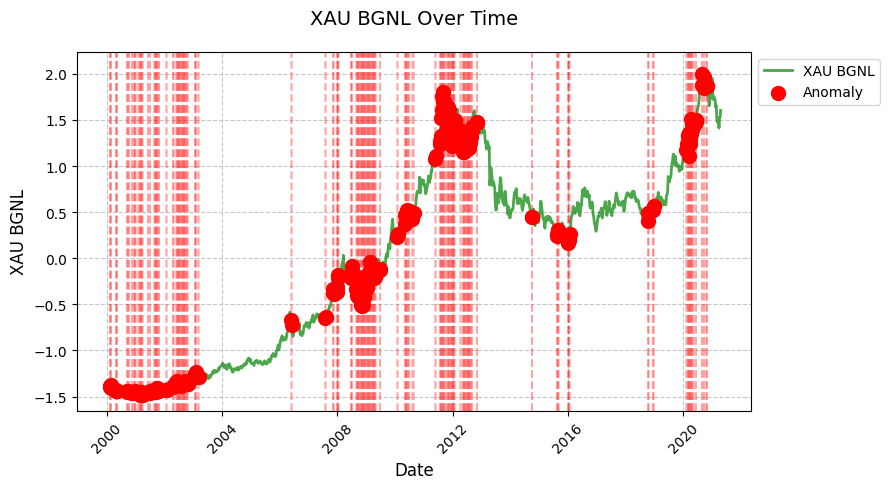

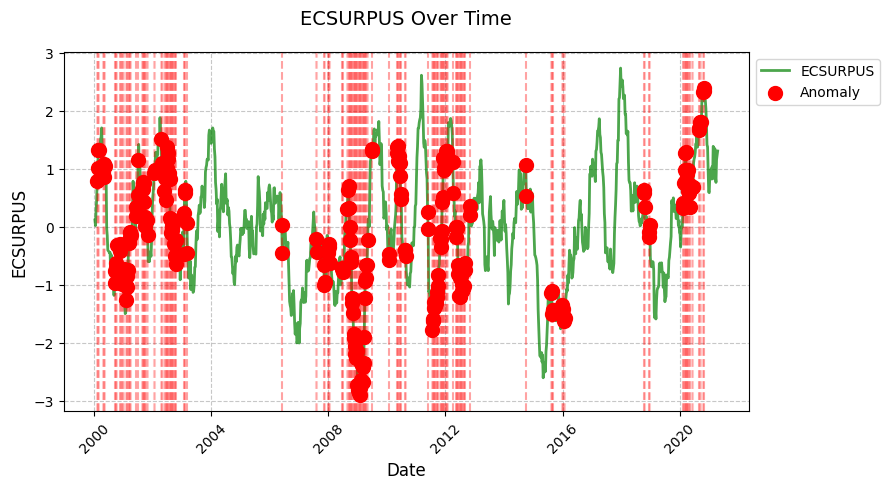

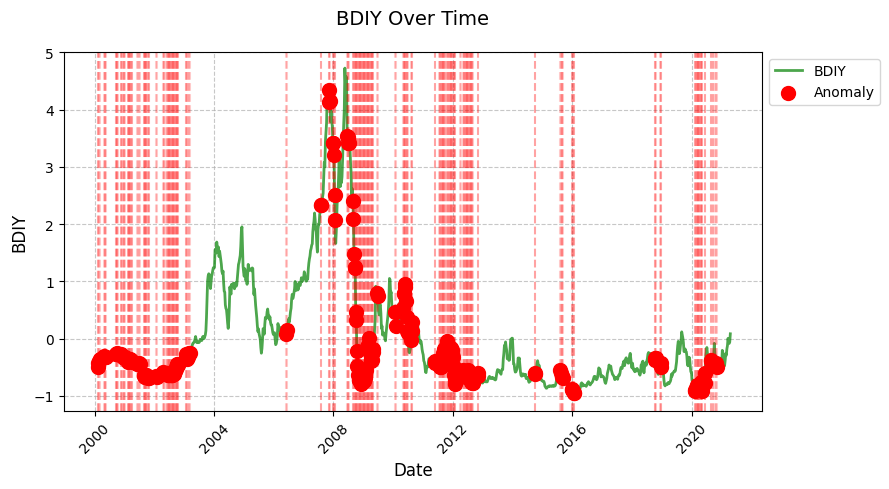

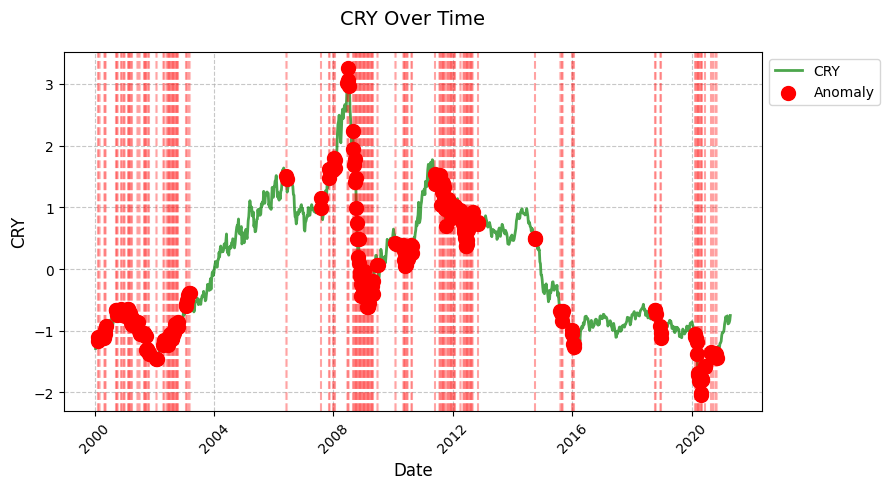

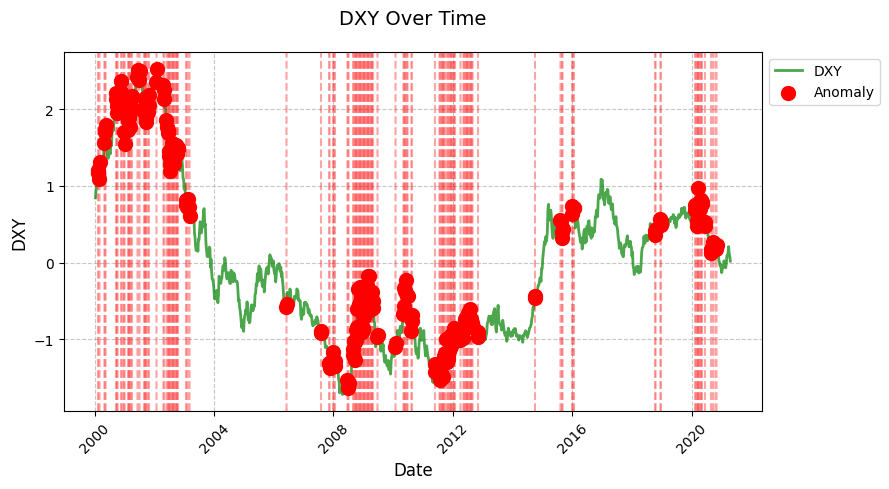

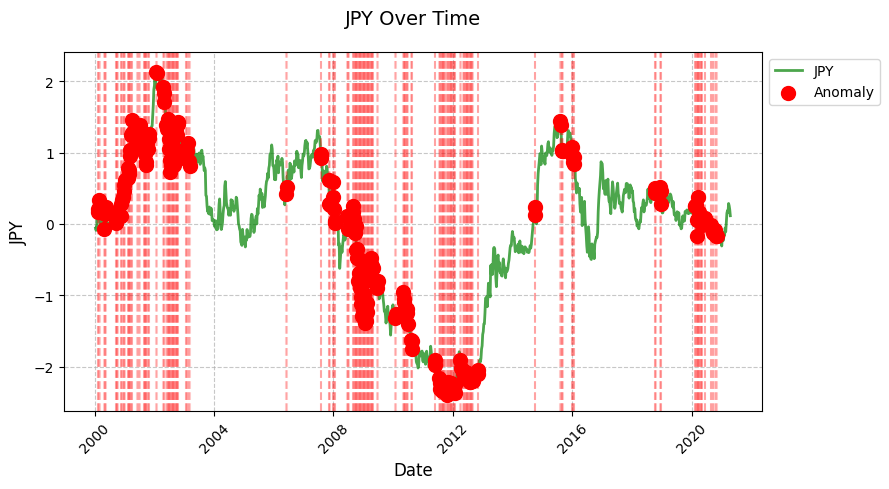

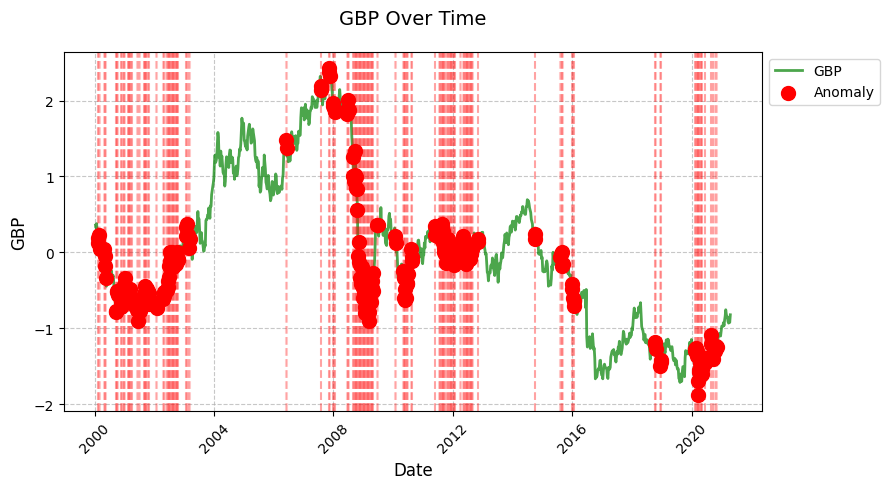

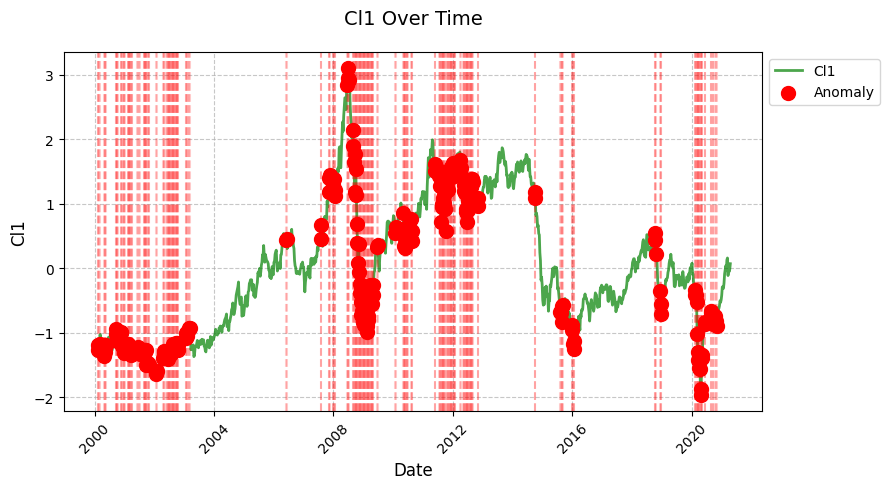

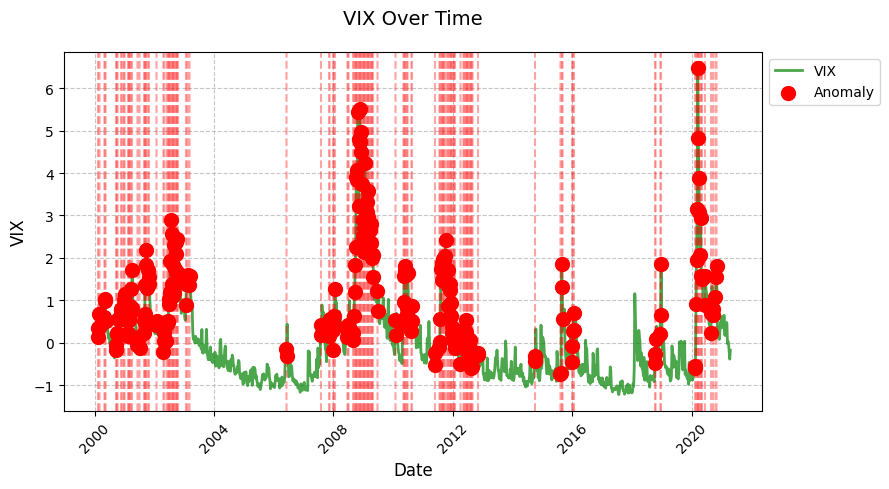

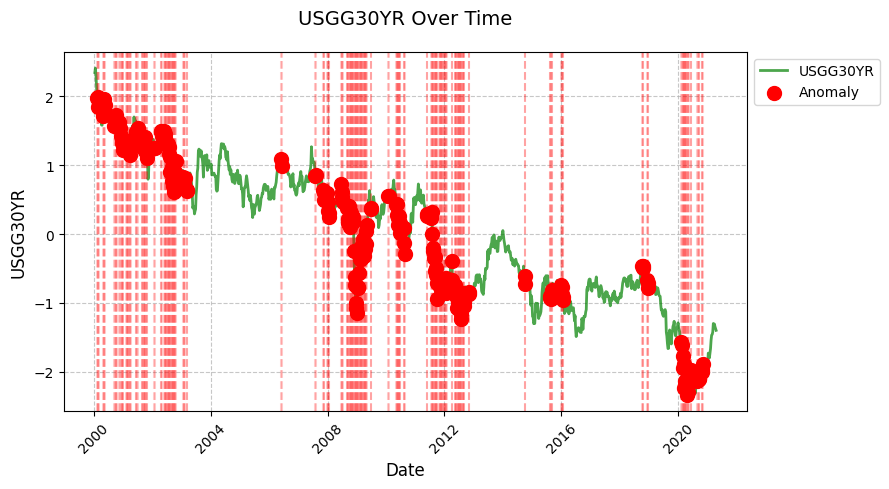

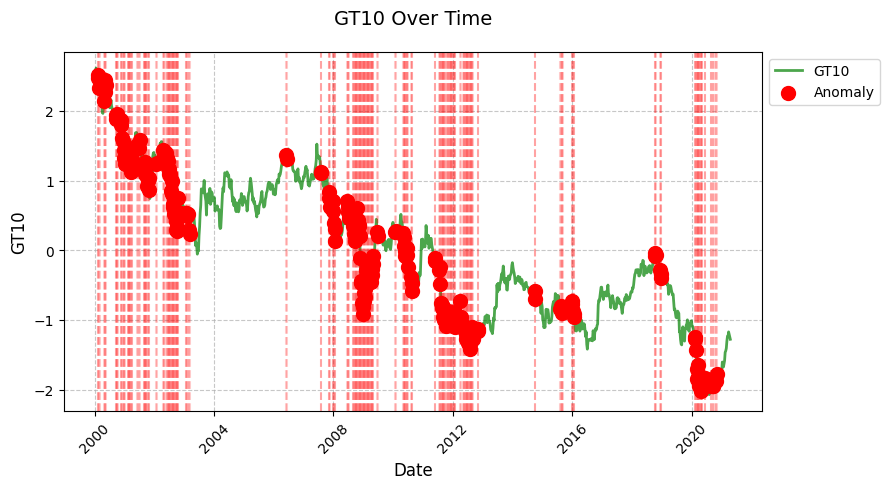

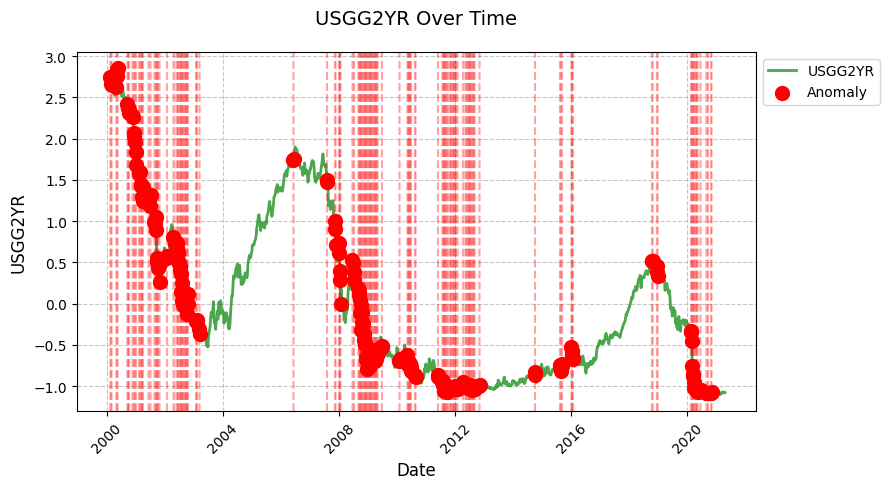

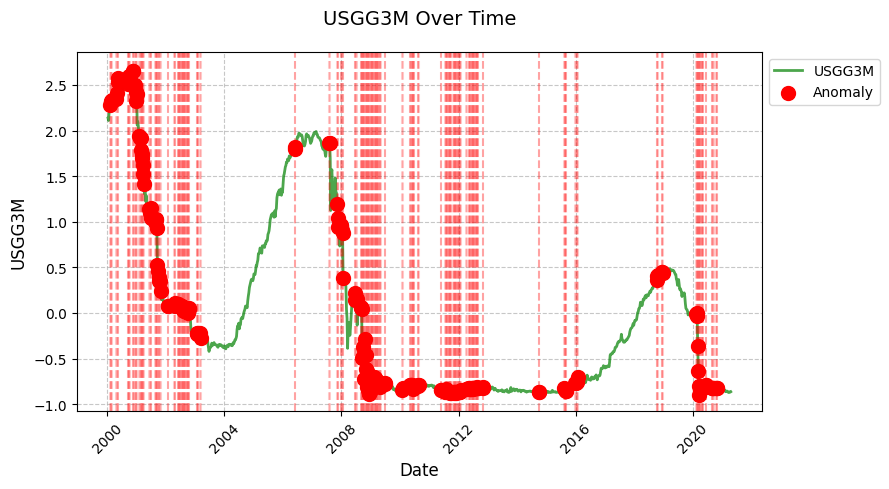

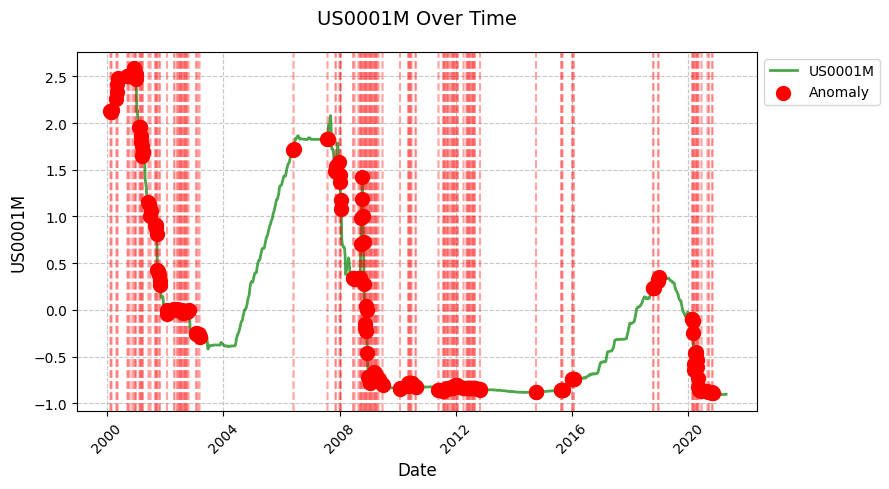

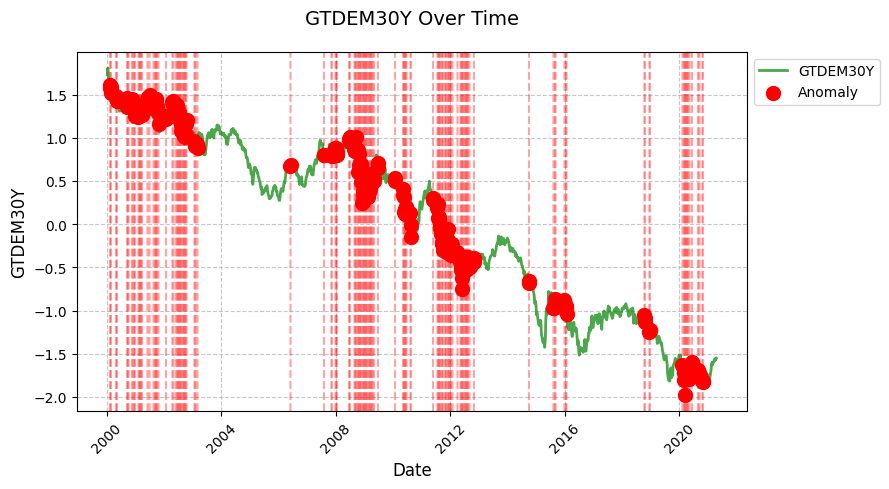

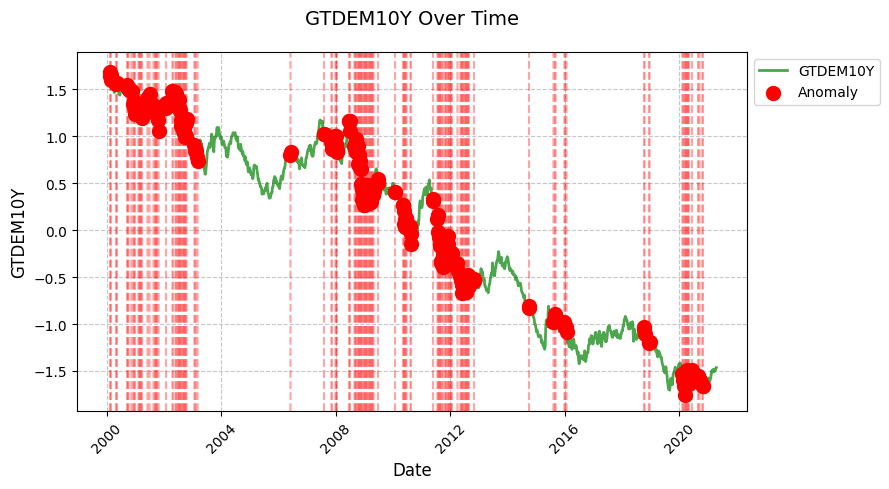

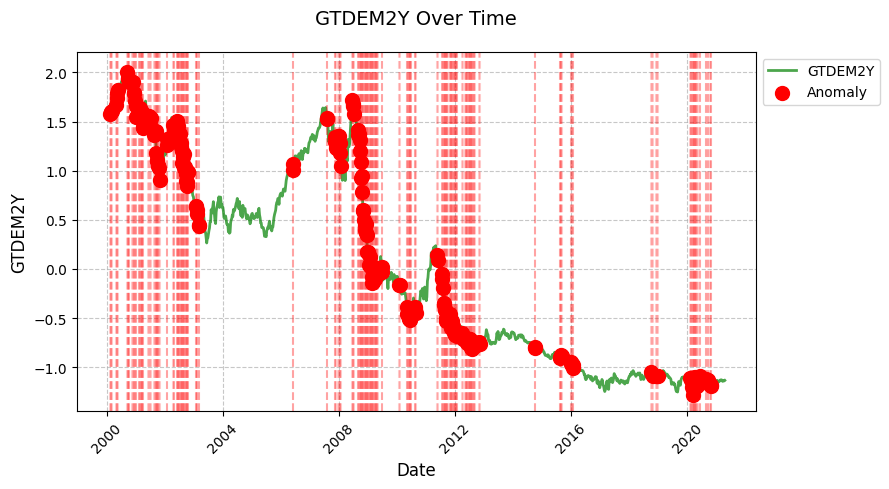

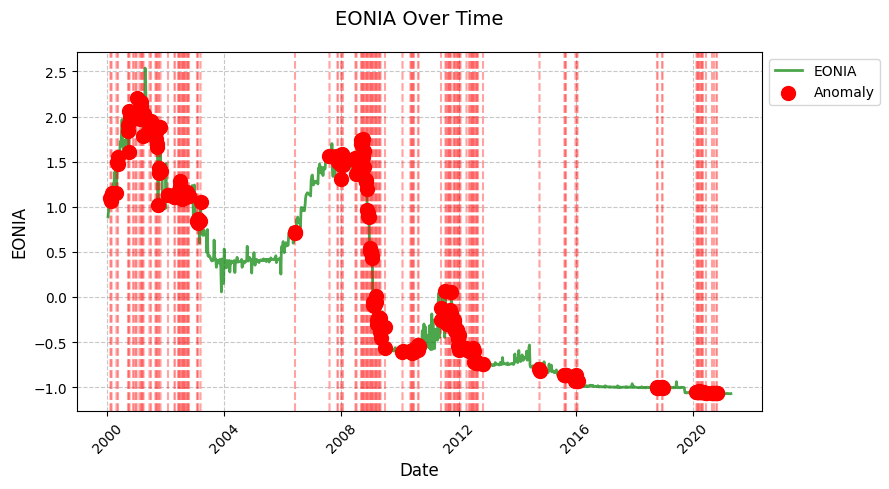

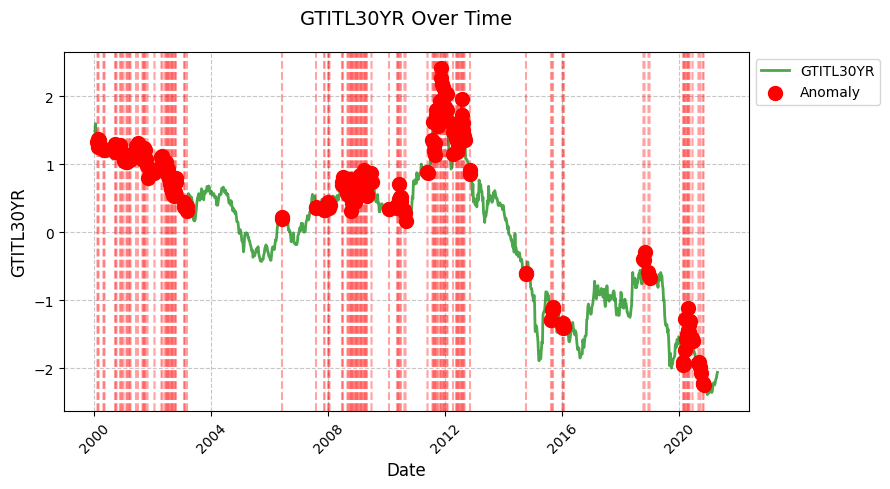

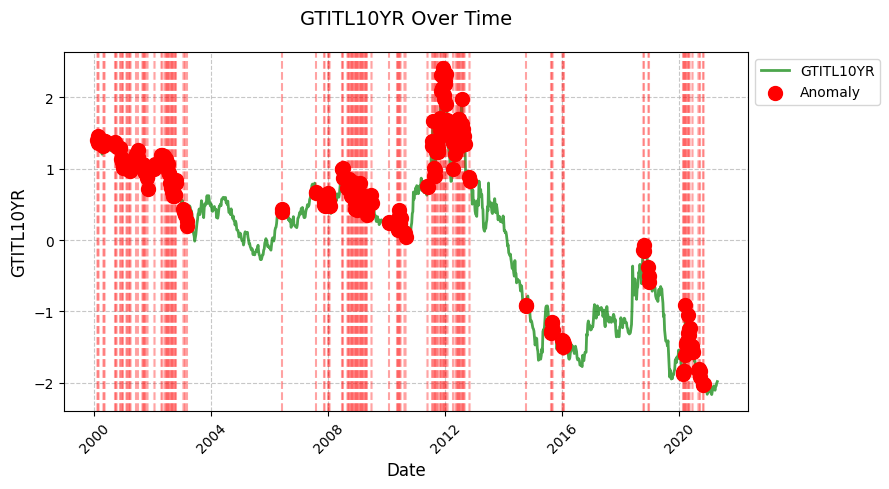

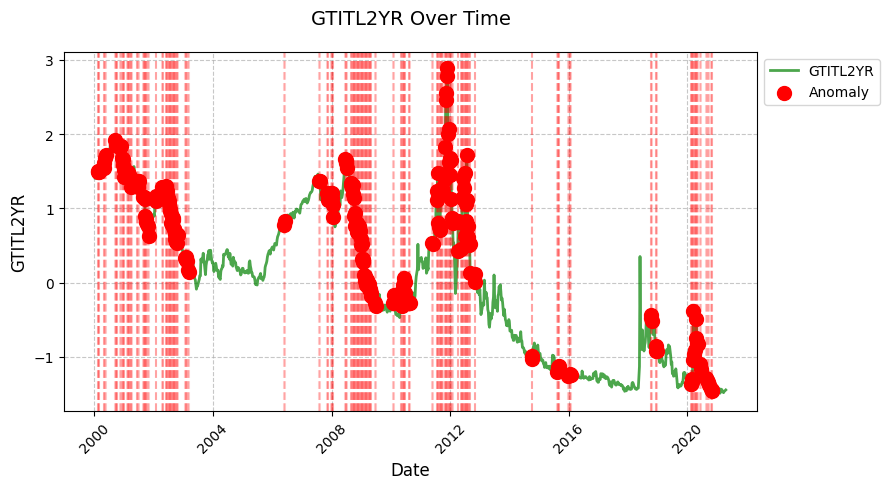

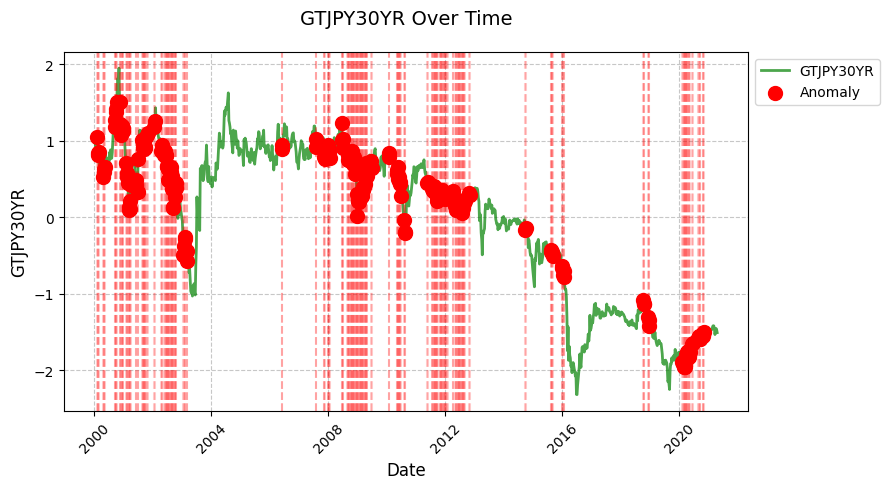

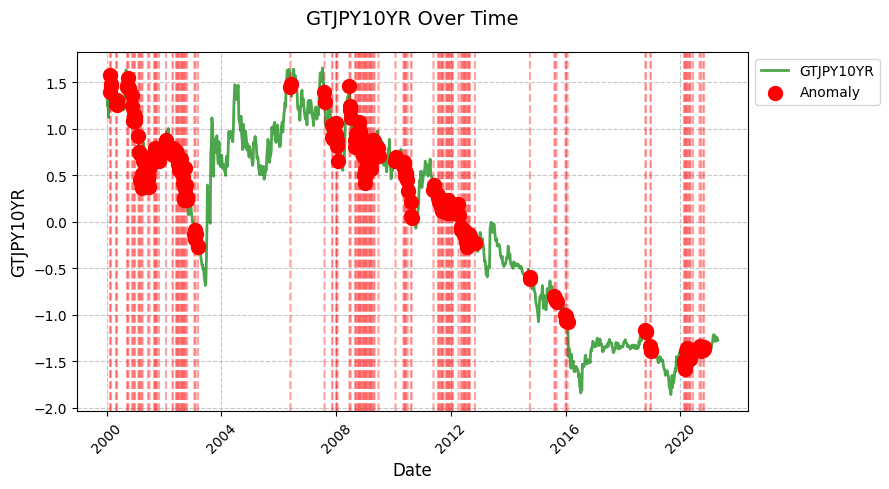

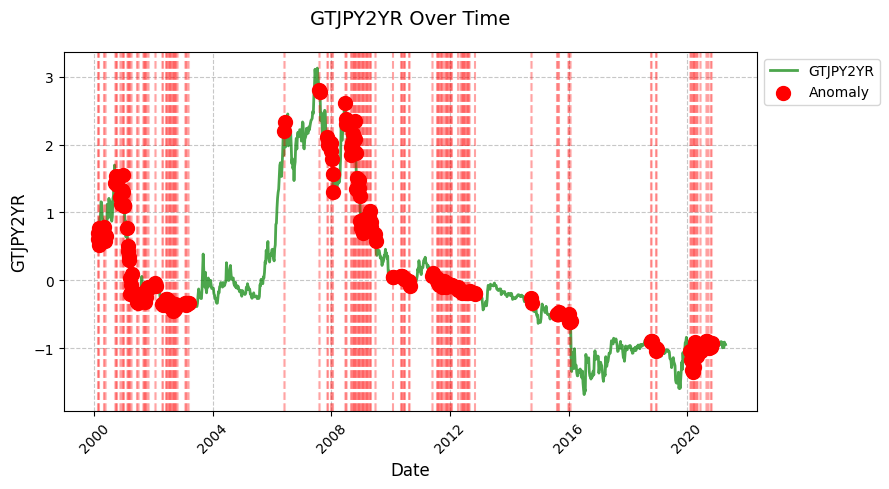

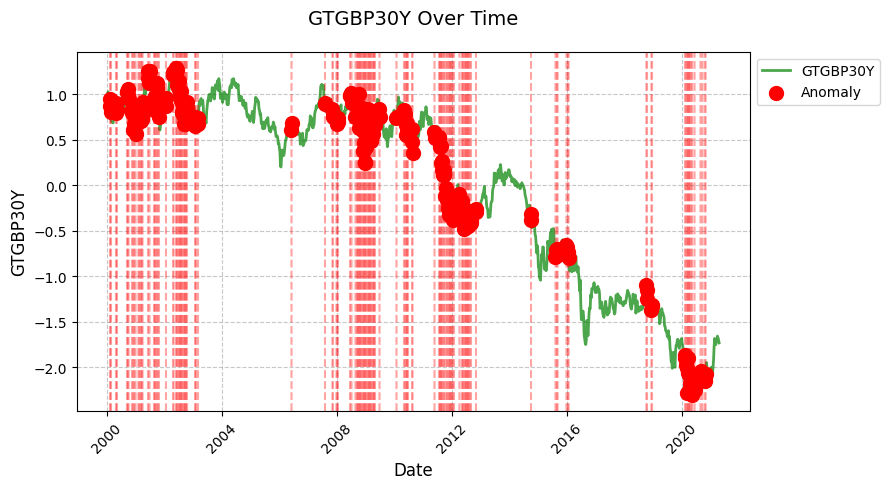

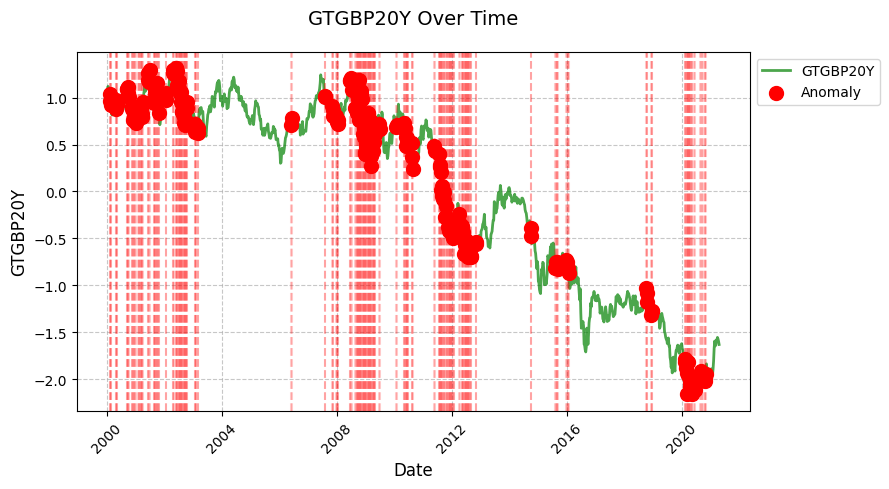

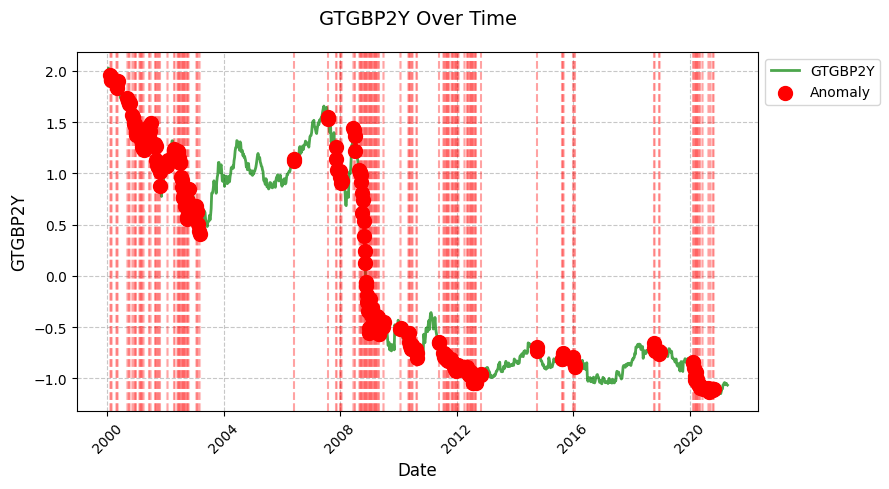

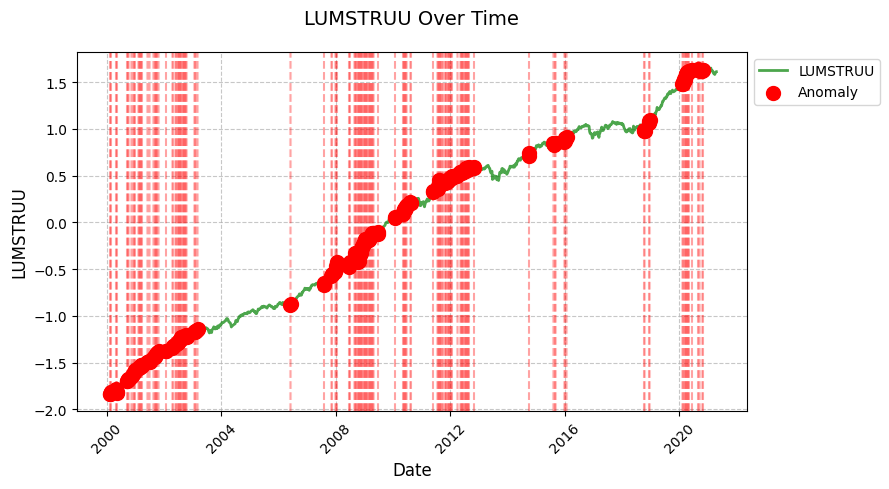

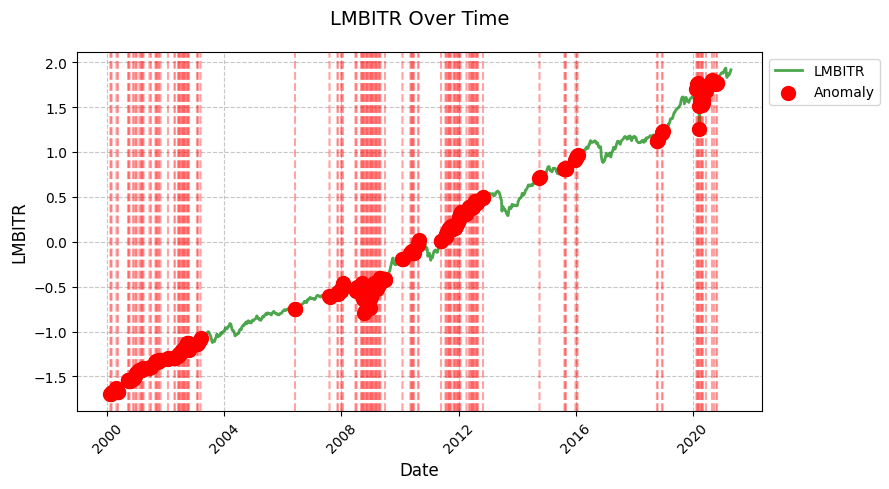

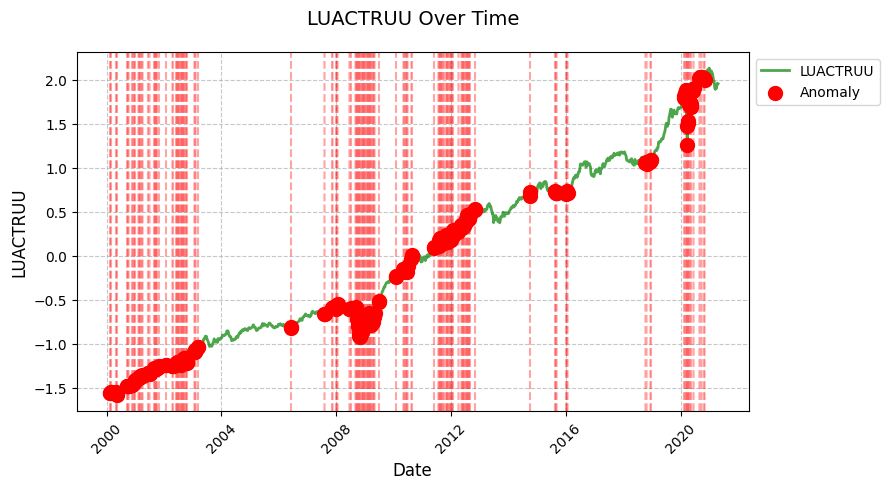

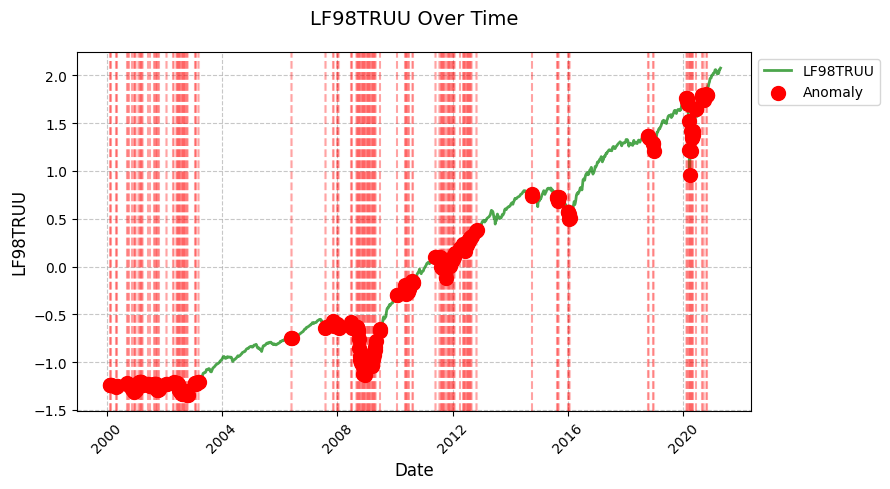

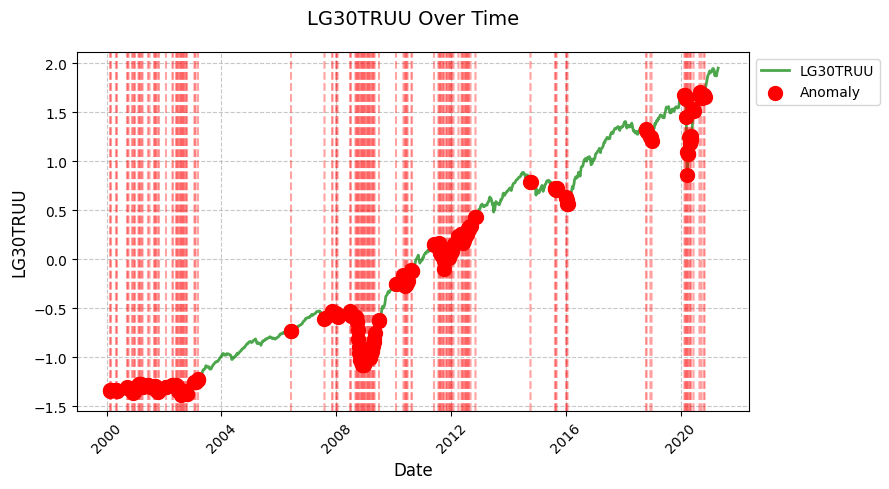

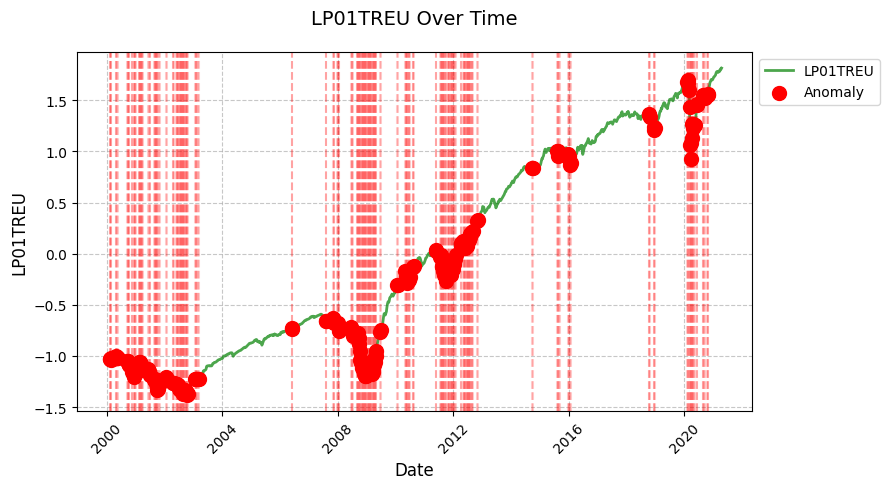

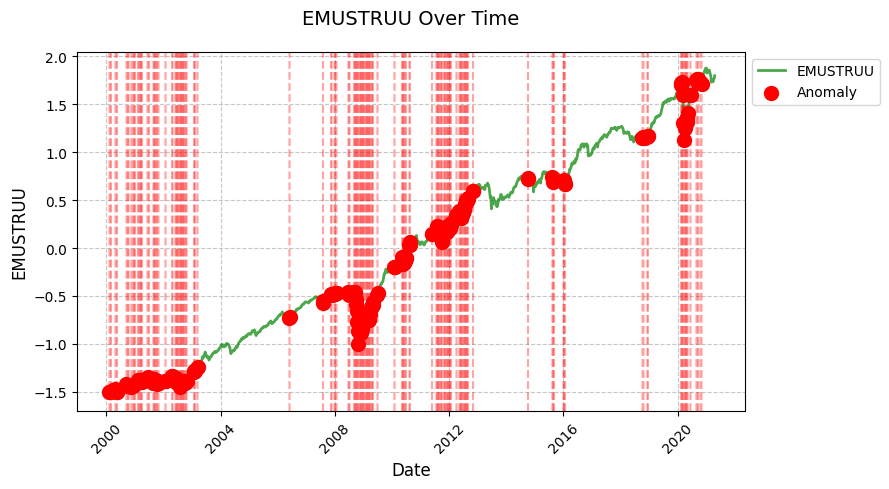

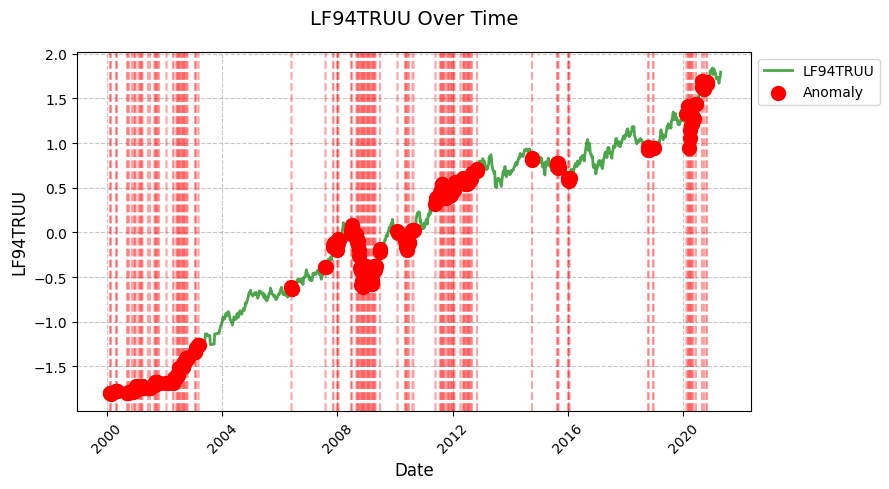

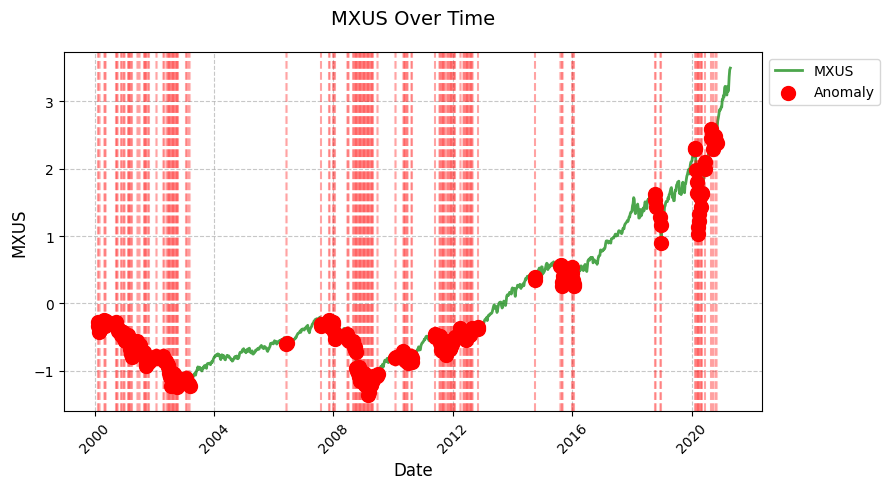

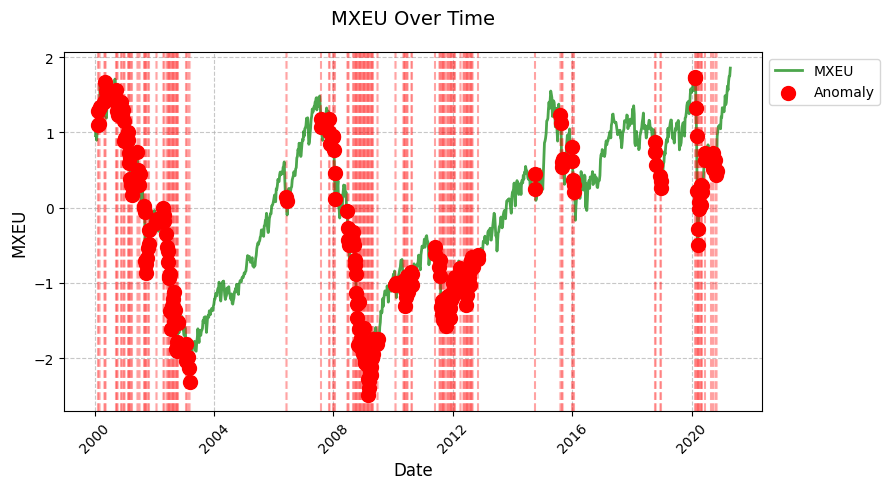

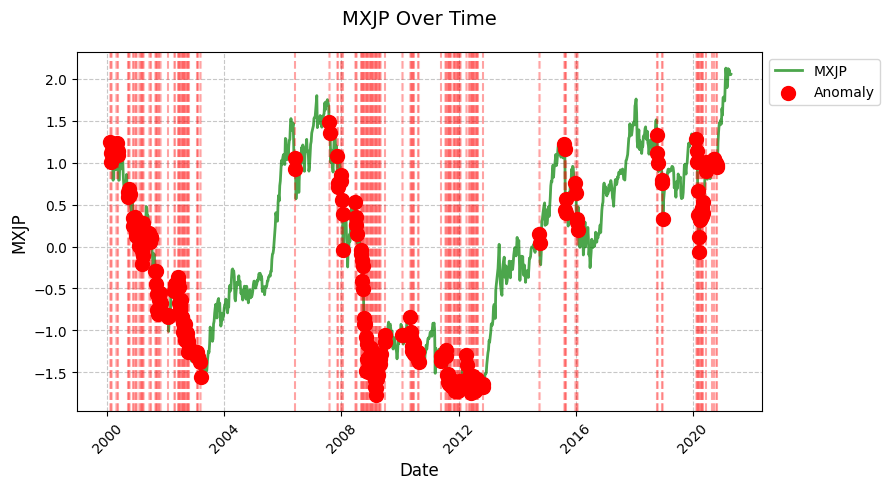

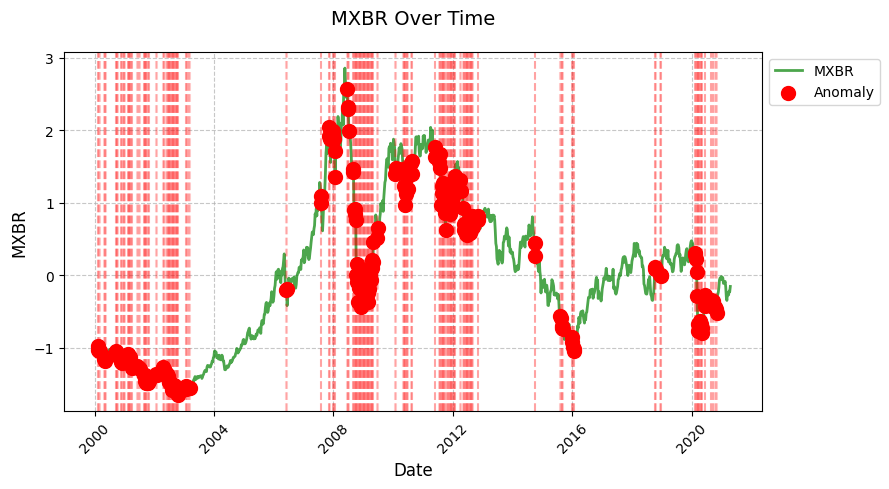

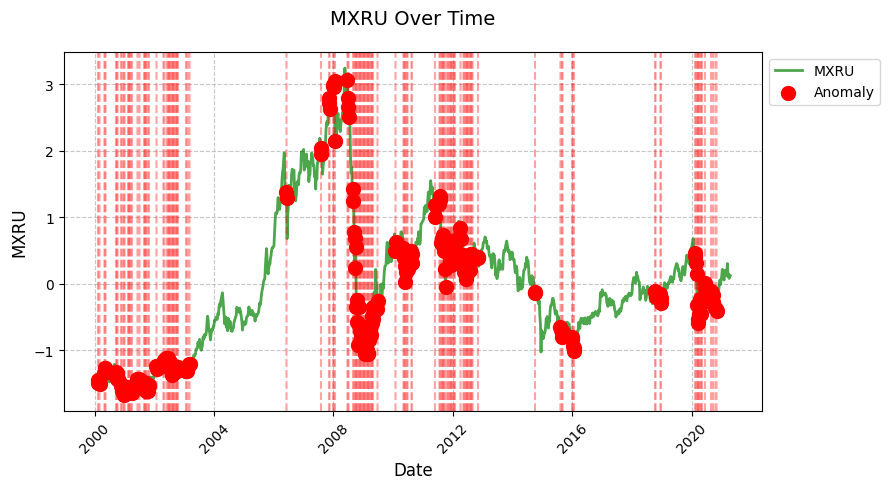

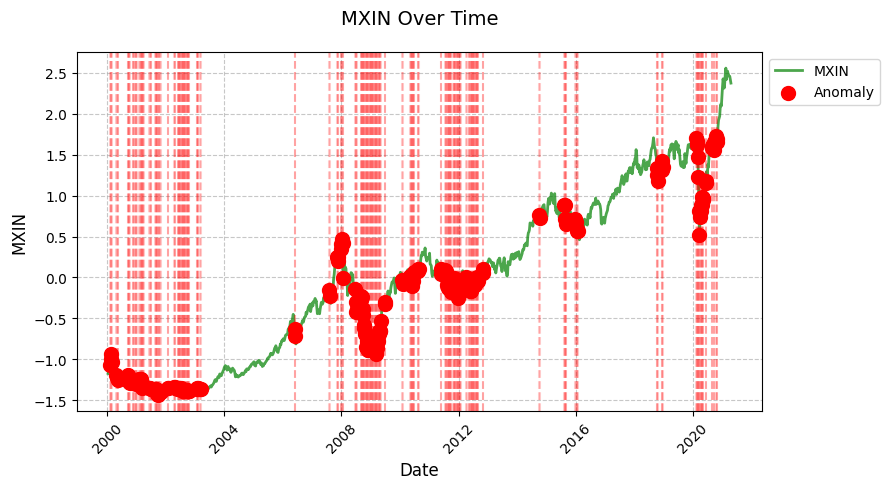

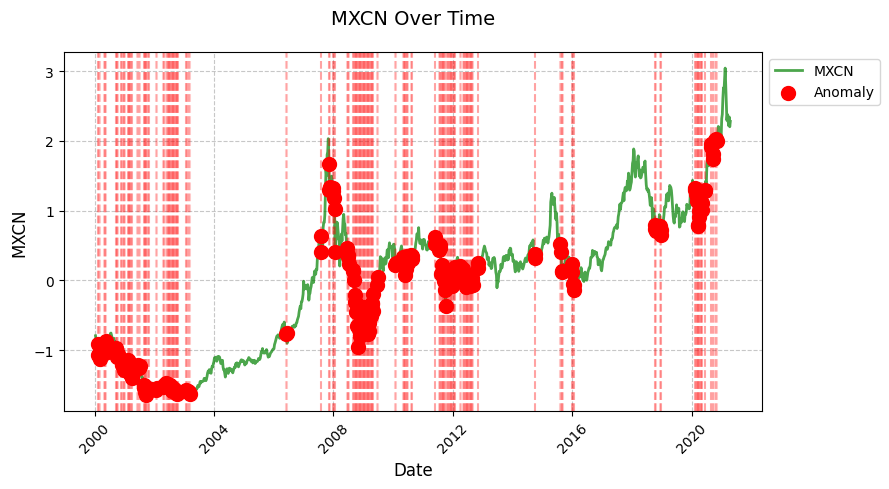

In [ ]:
plot_data_with_anomalies(data, figsize=(9, 5))

In [ ]:
def calculate_correlation_matrix(data):
  numeric_data = data.select_dtypes(include=[np.number])  # Select only numeric columns
  correlation_matrix = numeric_data.corr()
  plt.figure(figsize=(40, 30))
  sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
  plt.title('Correlation Matrix')
  plt.show()
  return correlation_matrix

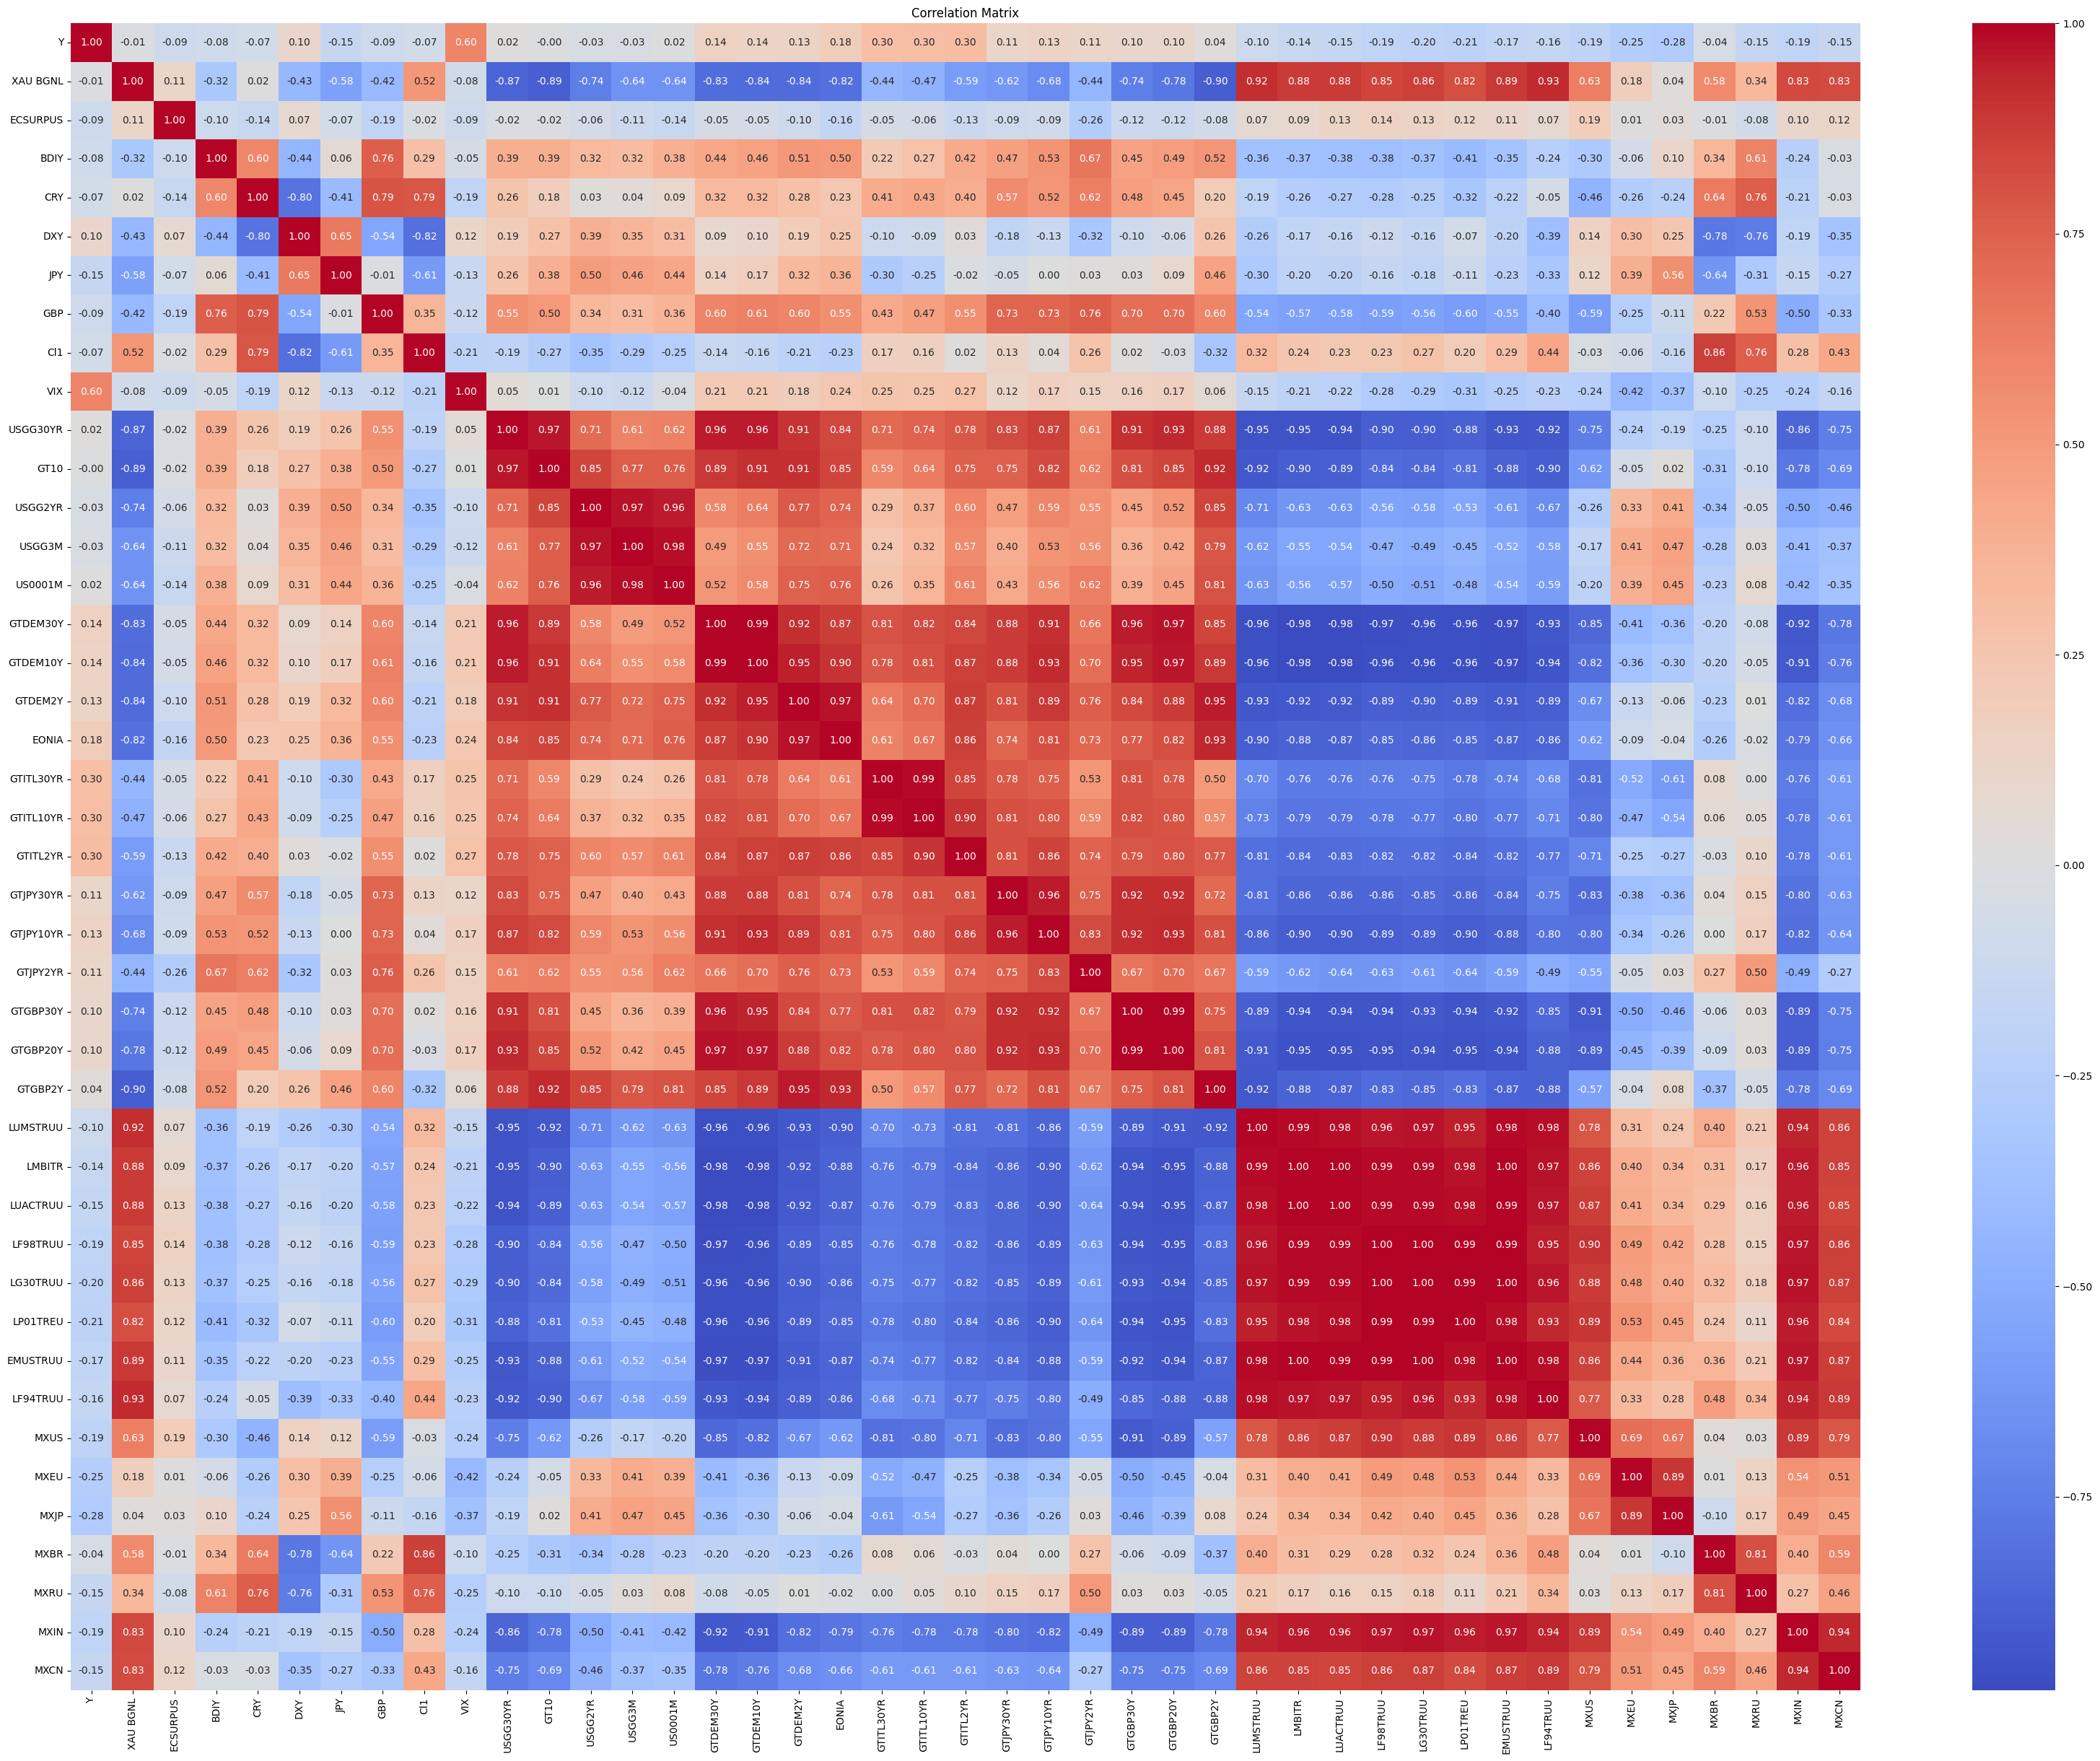

In [ ]:
correlation_matrix = calculate_correlation_matrix(data)

In [ ]:
def correlated_pair(correlation_matrix, threshold=0.8):
  high_corr_pairs = (
      correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1) > 0)
      .stack()
      .reset_index()
      .rename(columns={0: 'correlation', 'level_0': 'feature_1', 'level_1': 'feature_2'})
  )

  # Filter pairs with absolute correlation above the threshold
  high_corr_pairs = high_corr_pairs.loc[high_corr_pairs['correlation'].abs() > threshold]

  return high_corr_pairs

In [ ]:
correlated_pair = correlated_pair(correlation_matrix)

In [ ]:
correlated_pair

,feature_1,feature_2,correlation
50,XAU BGNL,USGG30YR,-0.868696
51,XAU BGNL,GT10,-0.893317
55,XAU BGNL,GTDEM30Y,-0.828390
56,XAU BGNL,GTDEM10Y,-0.835680
57,XAU BGNL,GTDEM2Y,-0.837306
...,...,...,...
881,LF94TRUU,MXCN,0.887483
886,MXUS,MXIN,0.891200
888,MXEU,MXJP,0.894194
897,MXBR,MXRU,0.814317


In [ ]:
remove_col = ['EMUSTRUU',
              'MXCN',
              'LMBITR',
              'MXJP',
              'LP01TREU',
              'GTJPY30YR',
              'LG30TRUU',
              'LF94TRUU',
              'LF98TRUU',
              'USGG30YR',
              'USGG2YR',
              'GTITL30YR',
              'MXEU',
              'EONIA',
              'GTITL10YR',
              'GTGBP30Y',
              'LUACTRUU',
              'GTDEM2Y',
              'GTGBP2Y',
              'GTJPY10YR',
              'MXRU',
              'GTDEM30Y',
              'US0001M',
              'LUMSTRUU',
              'MXIN']

In [ ]:
def remove_columns(df, columns_to_remove):
    for col in columns_to_remove:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame. Skipping.")

    remaining_values = df.drop(columns=columns_to_remove, errors='ignore')
    return remaining_values

In [ ]:
data = remove_columns(data, remove_col)

In [ ]:
data

,Y,Date,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,GT10,USGG3M,GTDEM10Y,GTITL2YR,GTJPY2YR,GTGBP20Y,MXUS,MXBR
0,0,2000-01-11,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,0.290316,2.545494,2.136872,1.671041,1.405967,0.658474,0.969729,-0.273397,-1.061289
1,0,2000-01-18,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,0.174552,2.613819,2.110236,1.726695,1.429497,0.668562,1.119849,-0.255250,-0.991858
2,0,2000-01-25,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,0.350514,2.571773,2.212340,1.656992,1.415379,0.480253,1.064927,-0.316639,-1.030691
3,0,2000-02-01,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,0.400292,2.516963,2.293357,1.626734,1.432438,0.719001,0.987304,-0.317527,-1.075649
4,1,2000-02-08,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,0.145611,2.512458,2.276155,1.639161,1.490087,0.702188,0.968264,-0.279370,-0.971646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,0.035636,-1.234922,-0.872701,-1.508255,-1.482335,-0.975773,-1.599902,3.142187,-0.234767
1107,0,2021-03-30,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,-0.044241,-1.171852,-0.868484,-1.478537,-1.462922,-0.992587,-1.555964,3.192590,-0.271440
1108,0,2021-04-06,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,-0.216730,-1.207892,-0.865654,-1.494207,-1.459981,-0.911883,-1.571782,3.363323,-0.216624
1109,0,2021-04-13,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,-0.386903,-1.239427,-0.868484,-1.481239,-1.451746,-0.952235,-1.596607,3.466292,-0.225549


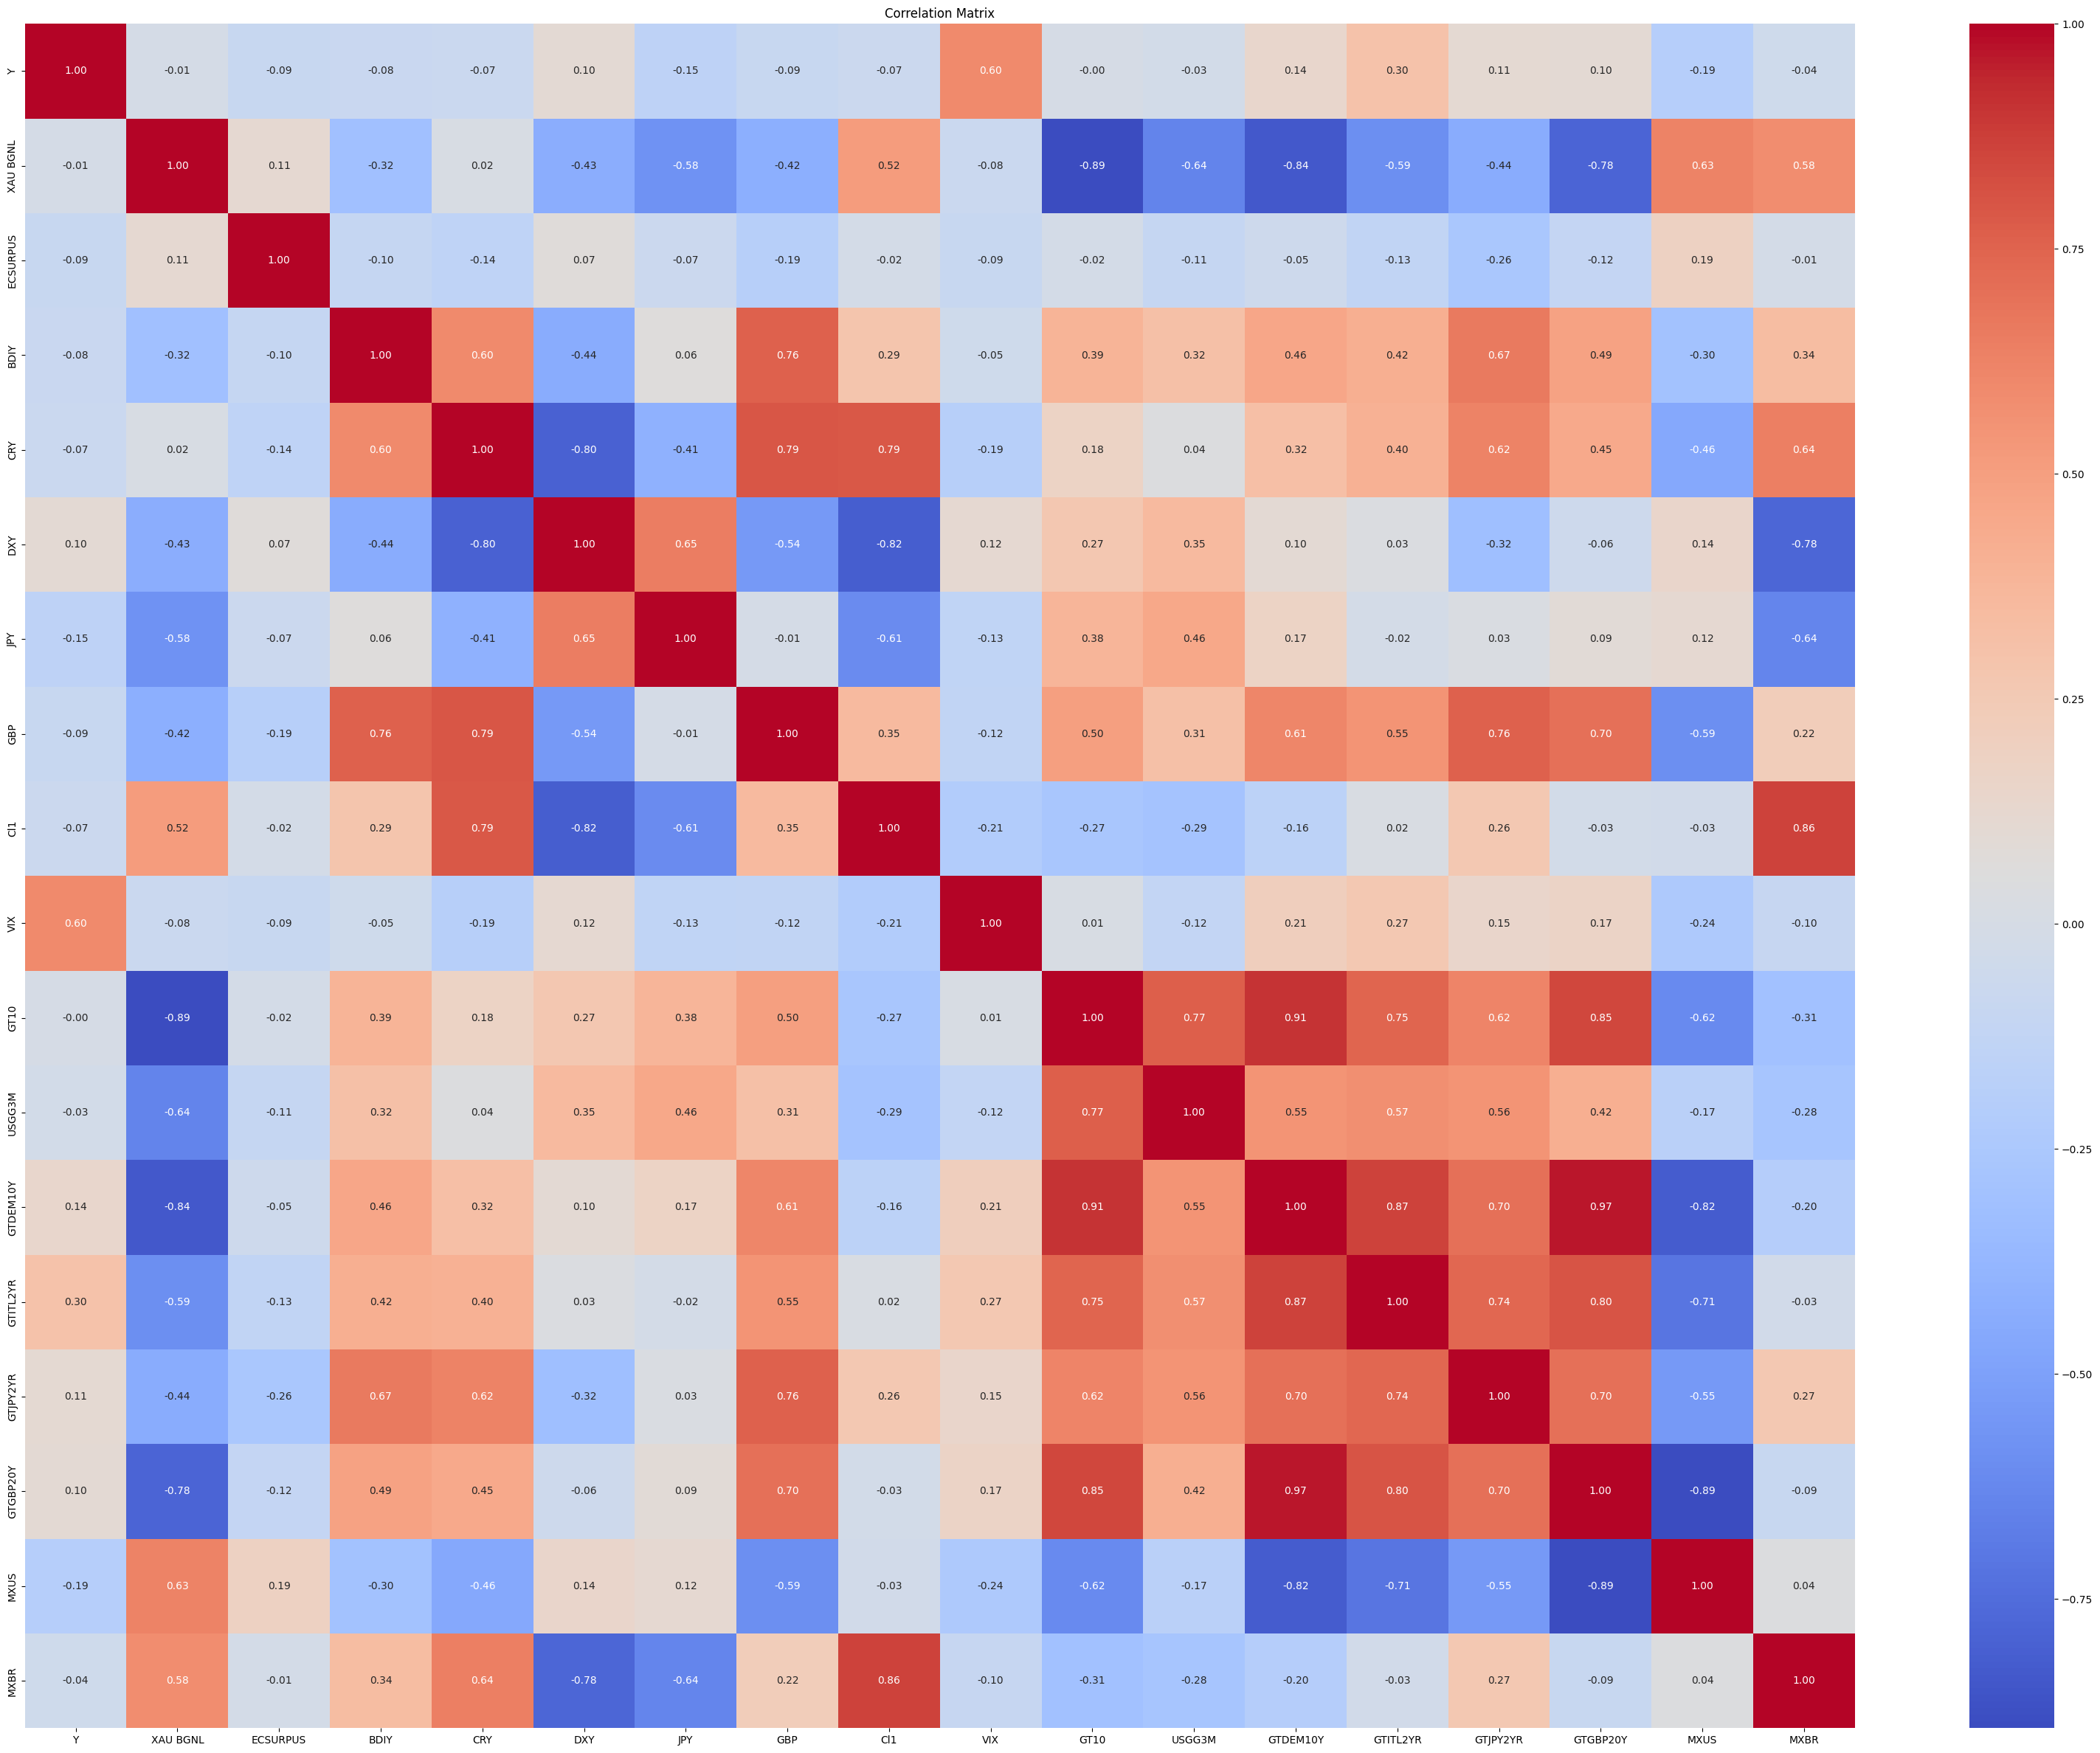

In [ ]:
correlation_matrix_result = calculate_correlation_matrix(data)

# Correlated Columns removed

# Add moving averages to relevant columsn

In [ ]:
mva = ['XAU BGNL', 'BDIY', 'CRY', 'DXY', 'JPY', 'GBP', 'VIX']

In [ ]:
def add_mv_columns(df, add_cols):
    for col in add_cols:
        if col + '_SMV' in df.columns or col+'_EMV' in df.columns:
            print(f"Warning: Column '{col}' moving avg already exists in DataFrame. Skipping.")
        else:
            df[col + '_SMV'] = df[col].rolling(30).mean()
            df[col + '_EMV'] = df[col].ewm(span=30, adjust=False).mean()

    for col in df.columns:
      if col not in ['Date', 'Y']:
        df[col] = df[col].interpolate(method='linear', limit_direction='both')

    return df

In [ ]:
data = add_mv_columns(data, mva)

In [ ]:
data

,Y,Date,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,CRY_SMV,CRY_EMV,DXY_SMV,DXY_EMV,JPY_SMV,JPY_EMV,GBP_SMV,GBP_EMV,VIX_SMV,VIX_EMV
0,0,2000-01-11,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,...,-1.025461,-1.289247,1.380698,0.846232,0.042613,-0.058102,-0.051484,0.359670,0.399019,0.290316
1,0,2000-01-18,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,...,-1.025461,-1.281921,1.380698,0.853606,0.042613,-0.060062,-0.051484,0.357238,0.399019,0.282848
2,0,2000-01-25,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,...,-1.025461,-1.272959,1.380698,0.863624,0.042613,-0.059031,-0.051484,0.358611,0.399019,0.287213
3,0,2000-02-01,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,...,-1.025461,-1.264944,1.380698,0.887233,0.042613,-0.048968,-0.051484,0.348041,0.399019,0.294509
4,1,2000-02-08,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,...,-1.025461,-1.258789,1.380698,0.905348,0.042613,-0.032266,-0.051484,0.338152,0.399019,0.284902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,...,-1.167531,-1.098360,0.075273,0.099232,-0.111186,-0.062606,-1.077030,-1.043920,0.563558,0.492379
1107,0,2021-03-30,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,...,-1.152131,-1.084571,0.078083,0.106228,-0.100096,-0.040047,-1.071894,-1.036683,0.538437,0.457759
1108,0,2021-04-06,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,...,-1.132672,-1.070759,0.074830,0.107315,-0.089838,-0.021005,-1.059691,-1.026781,0.486961,0.414243
1109,0,2021-04-13,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,...,-1.112951,-1.055666,0.071319,0.105593,-0.080151,-0.006660,-1.046436,-1.020103,0.452463,0.362556


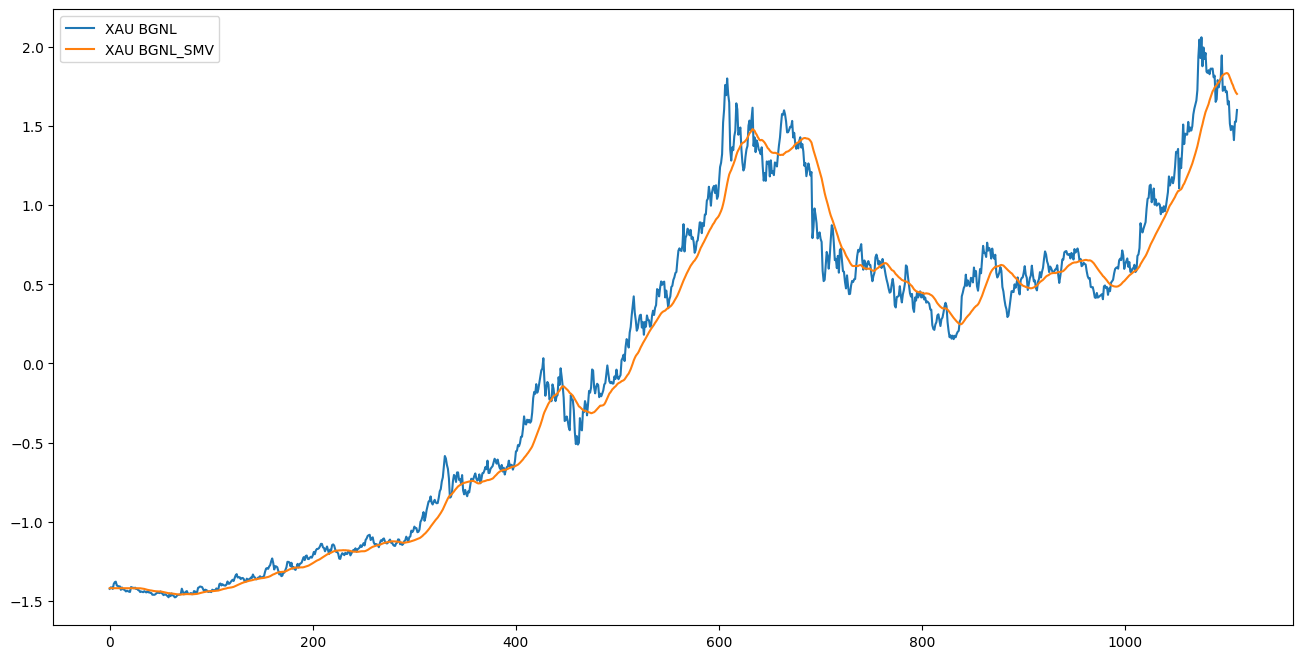

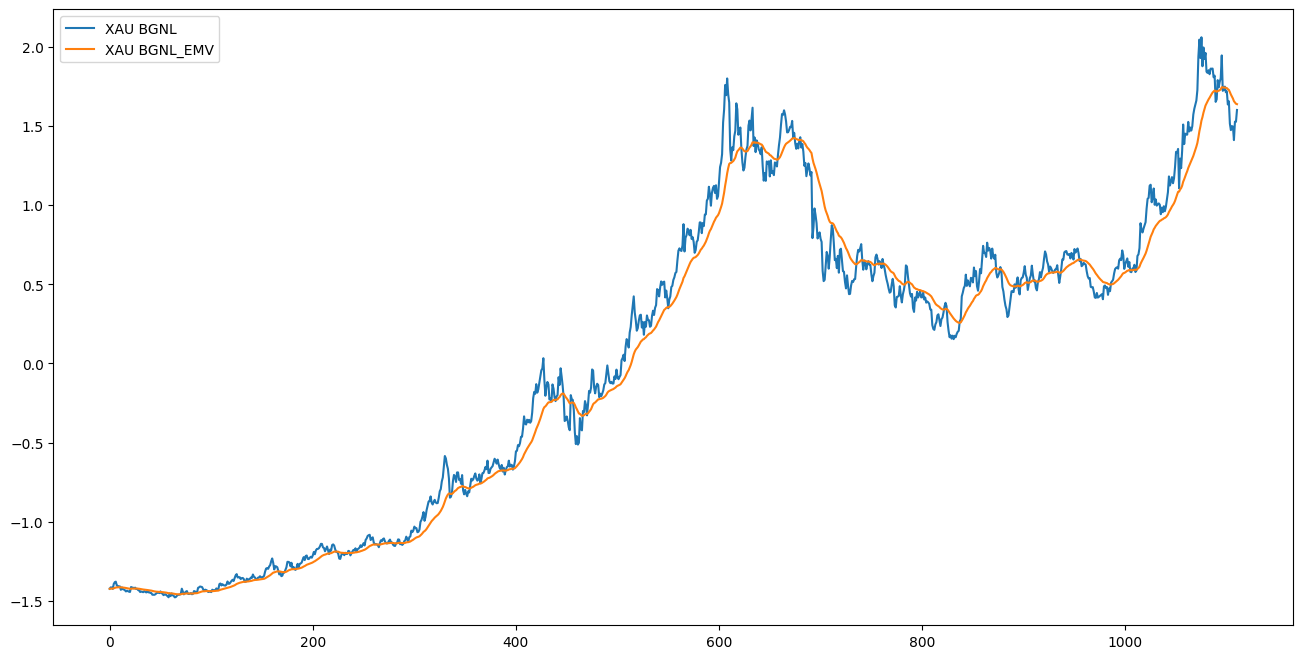

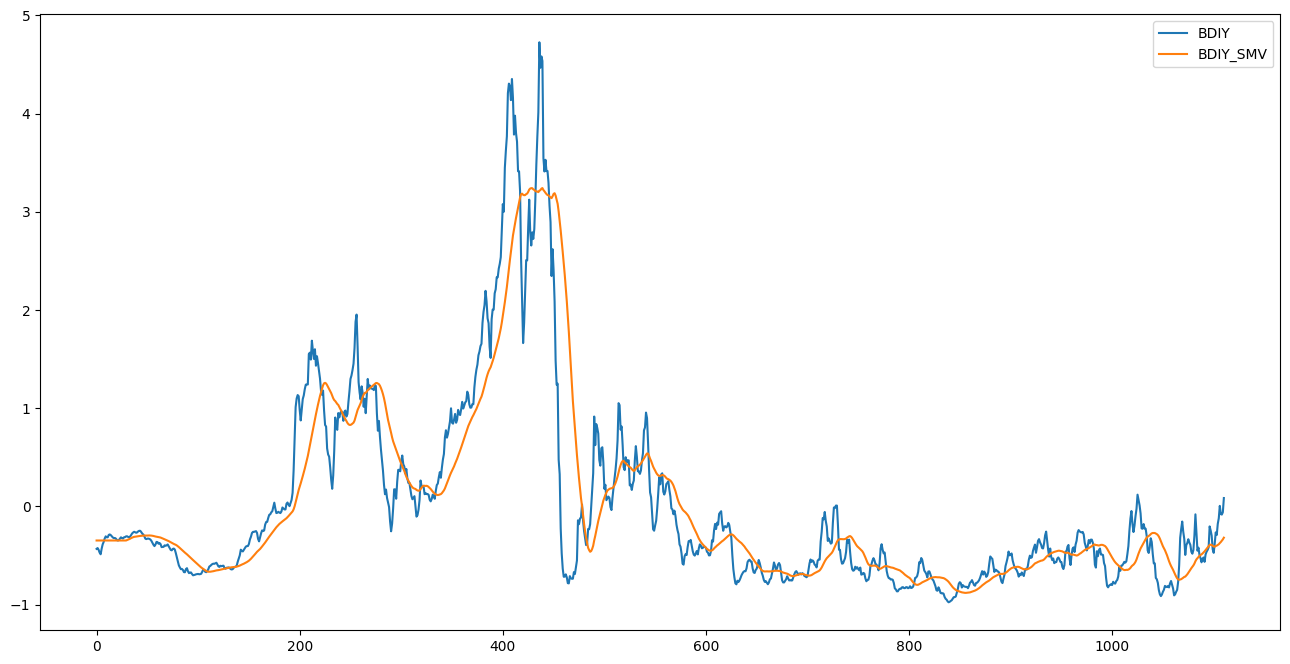

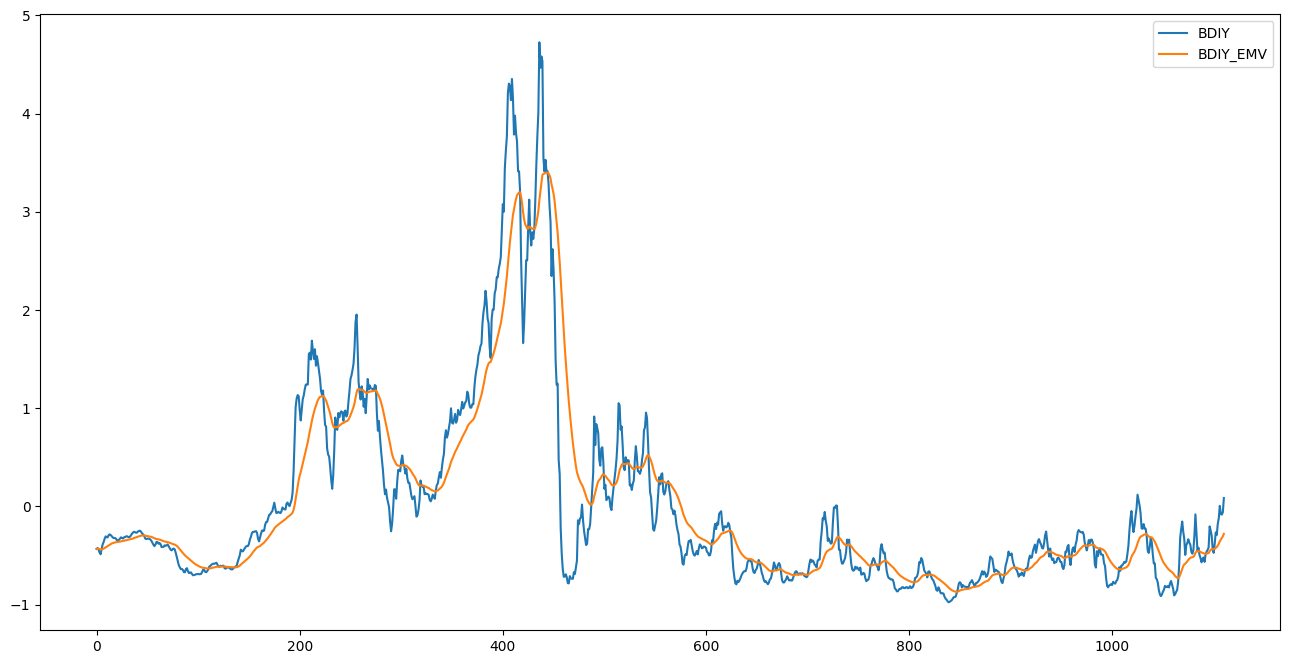

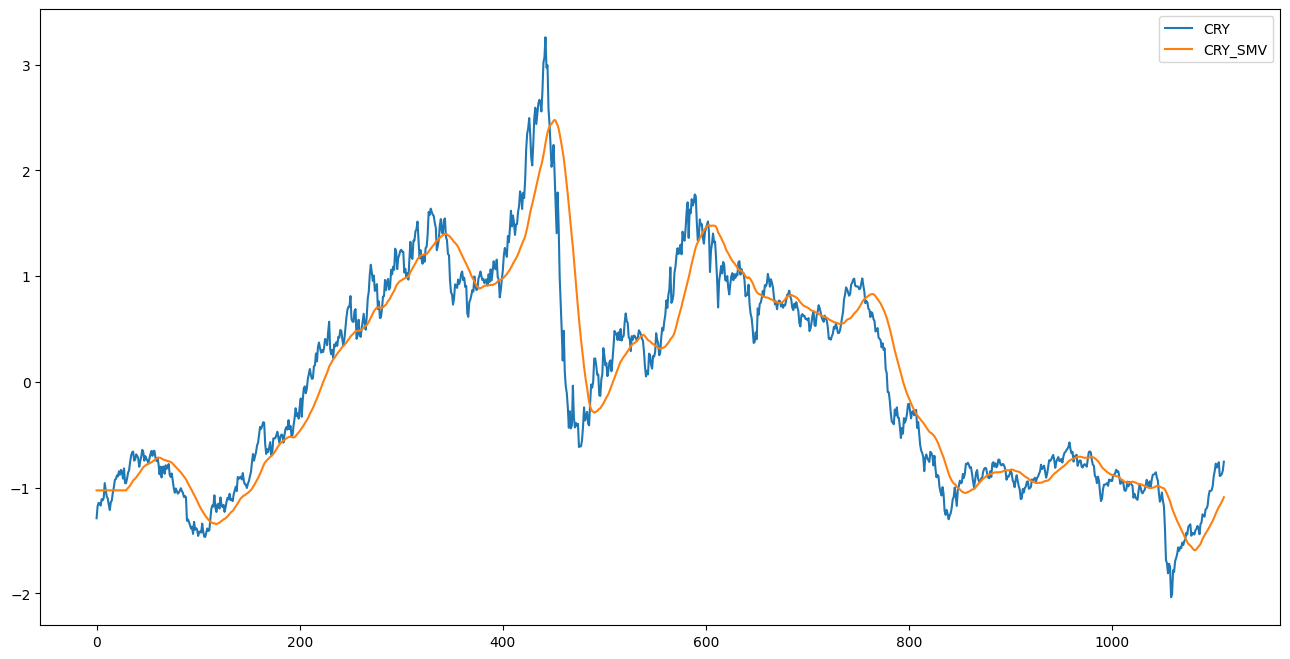

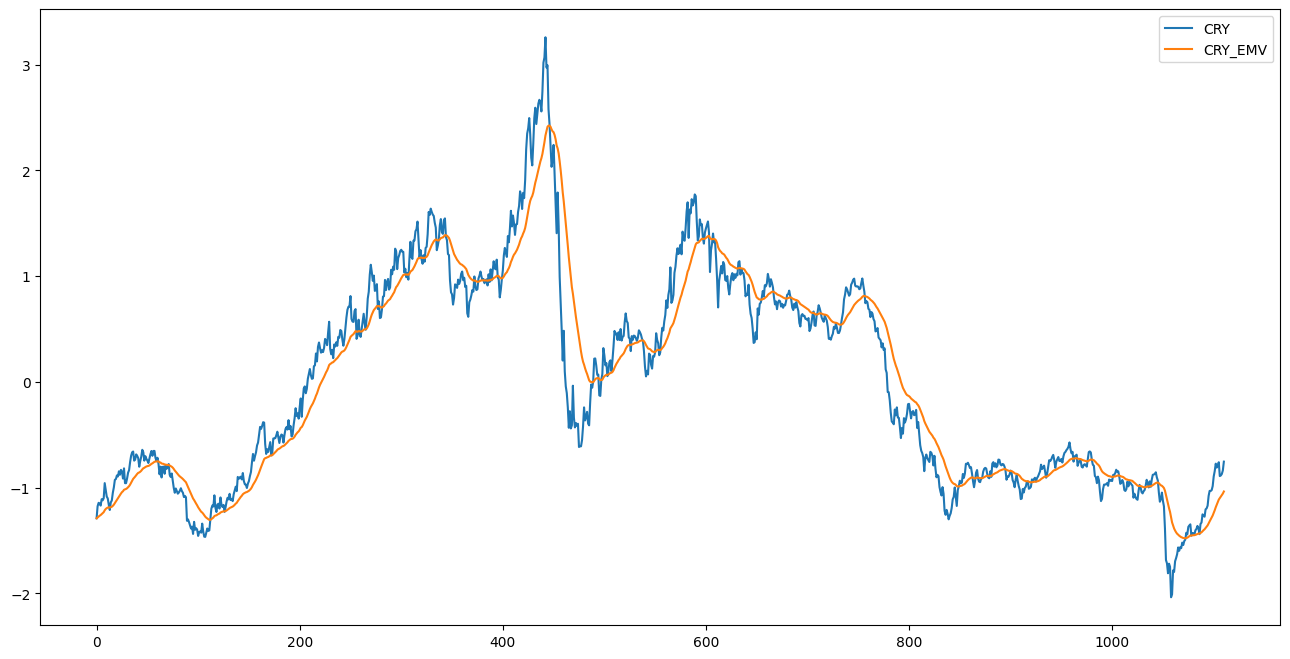

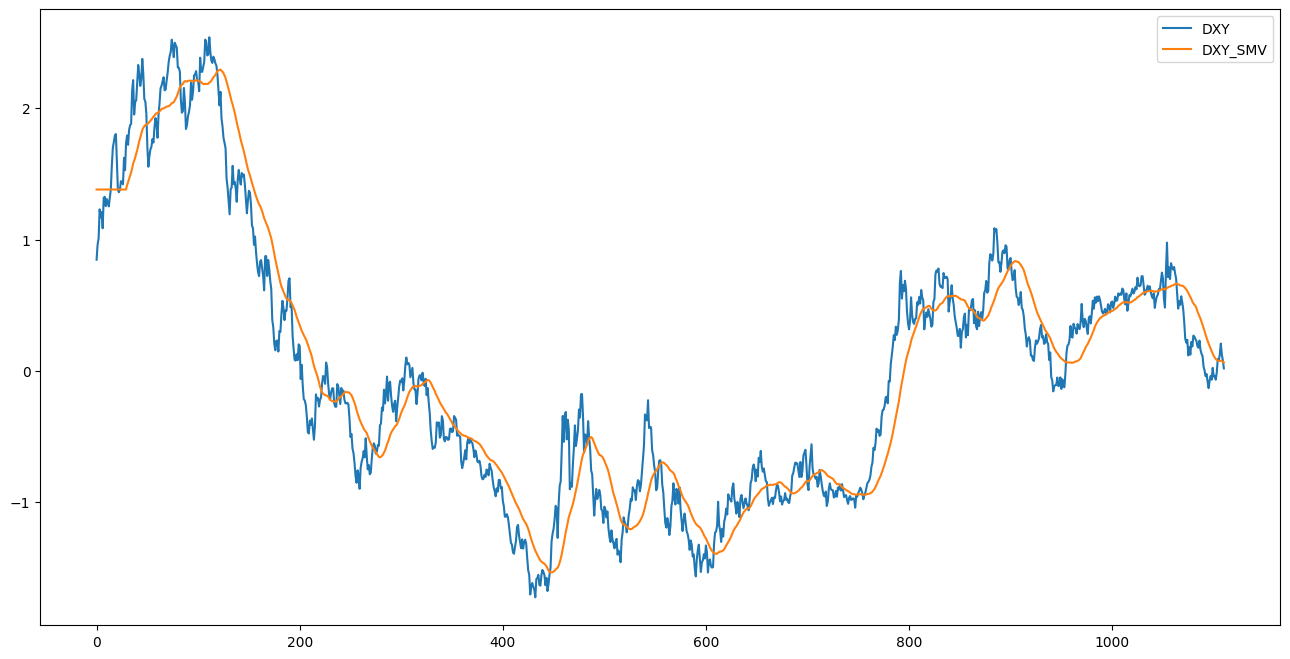

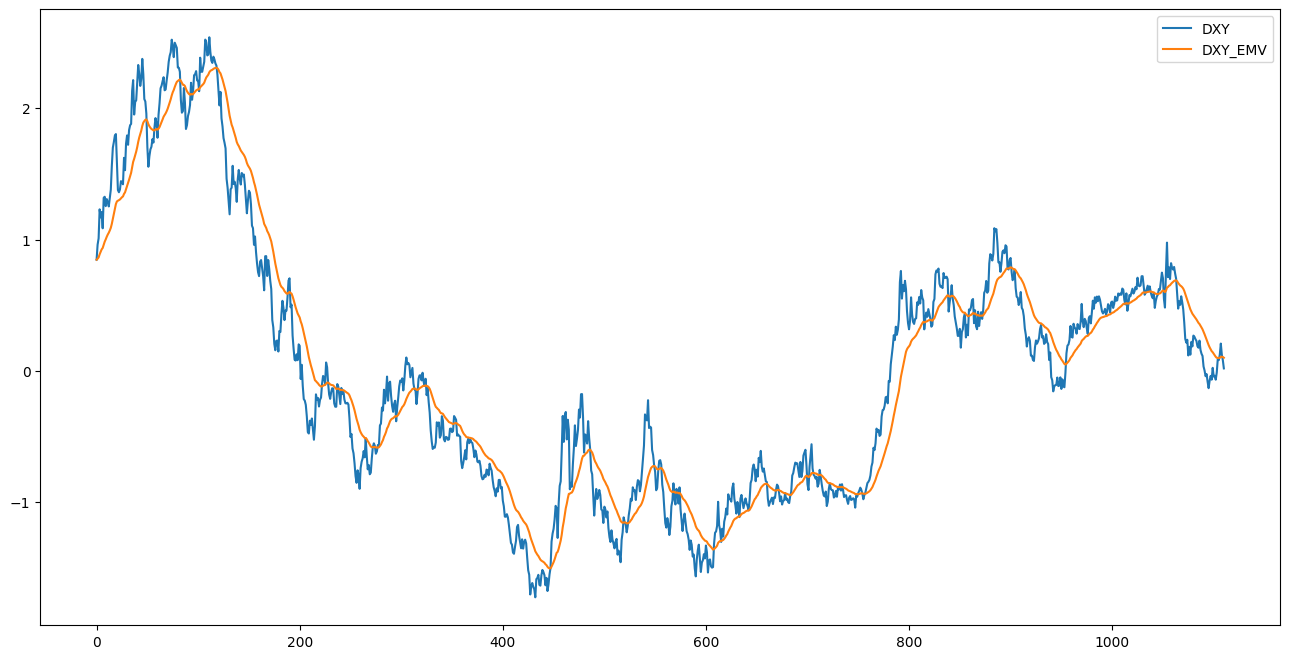

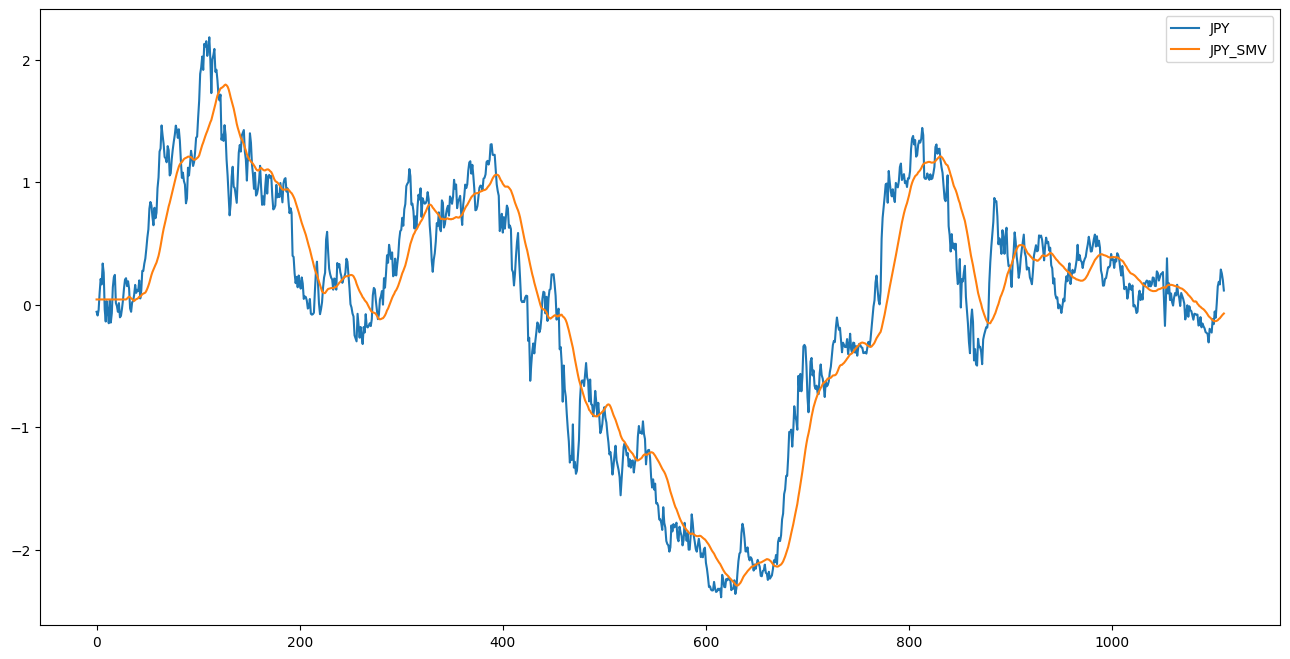

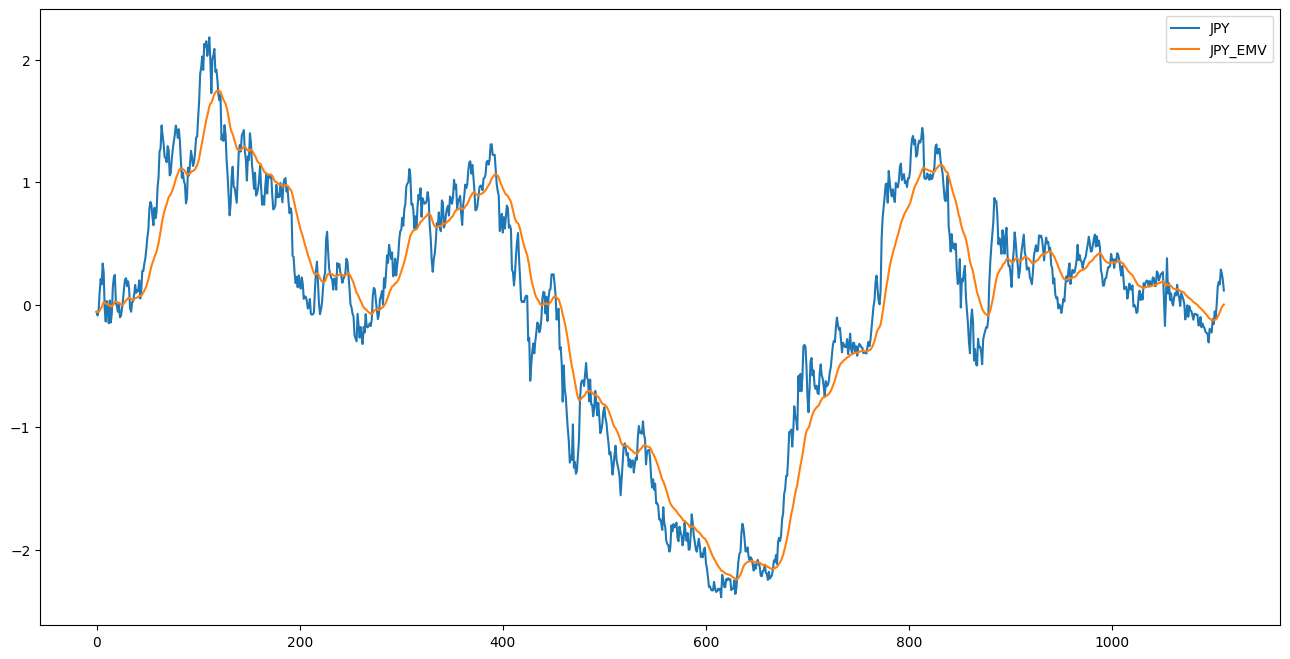

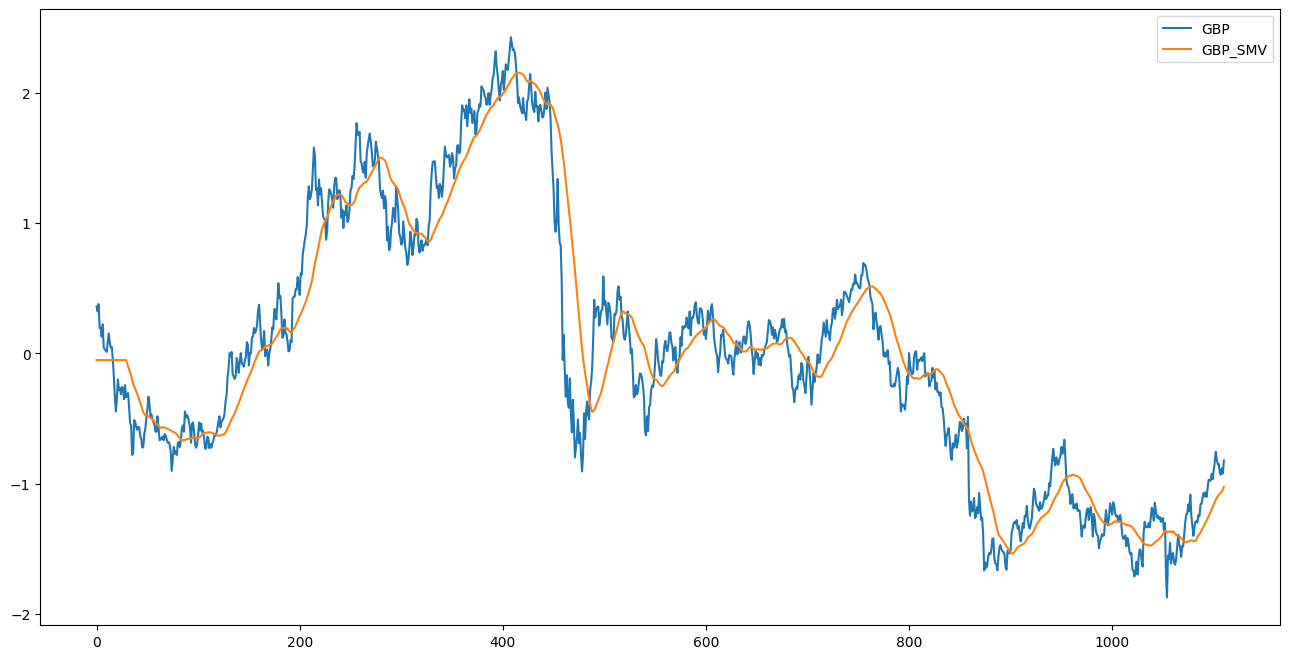

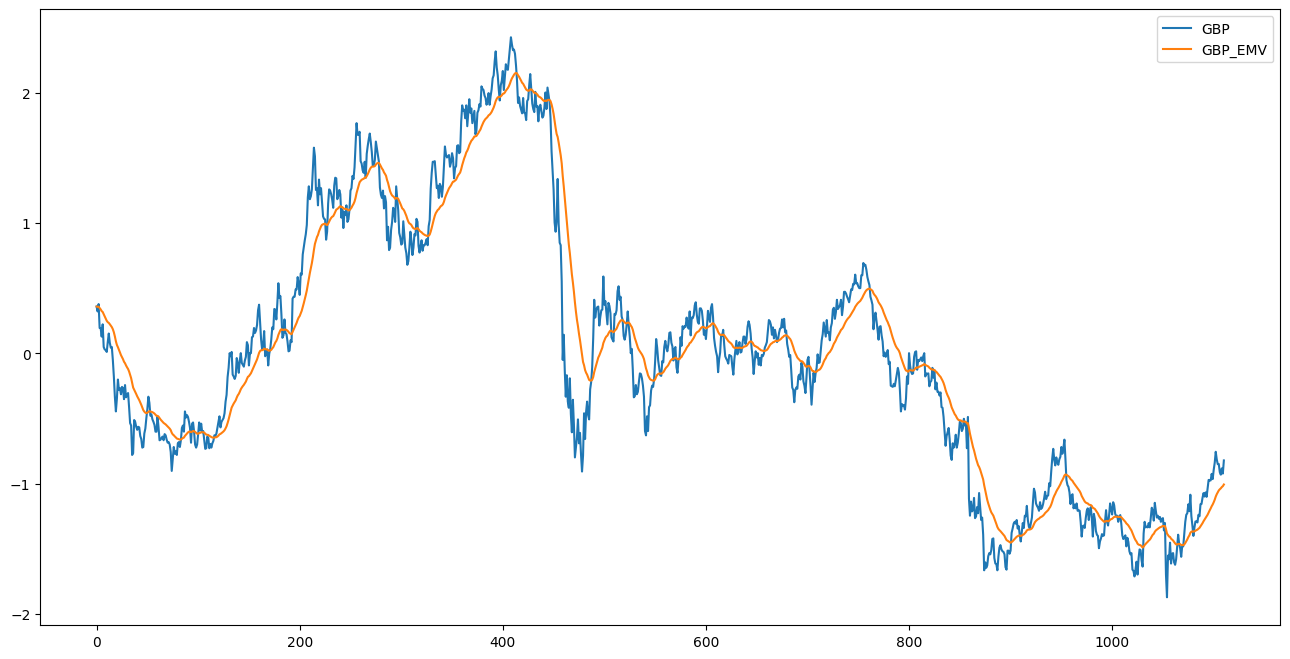

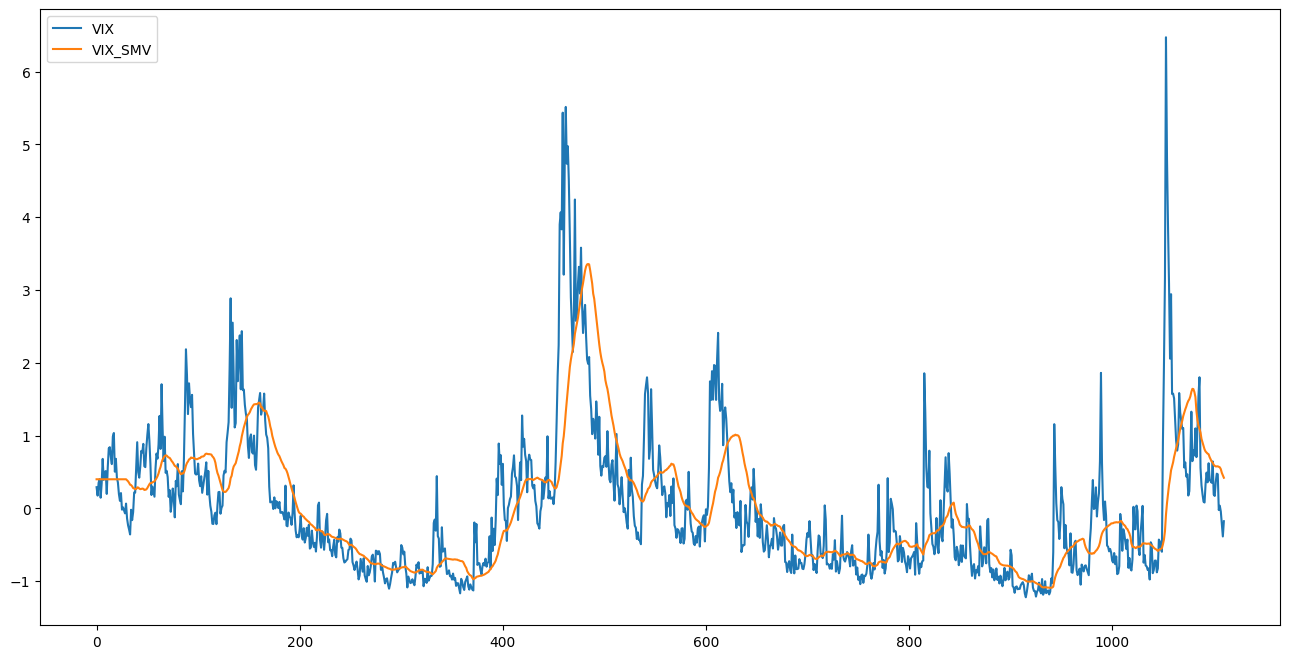

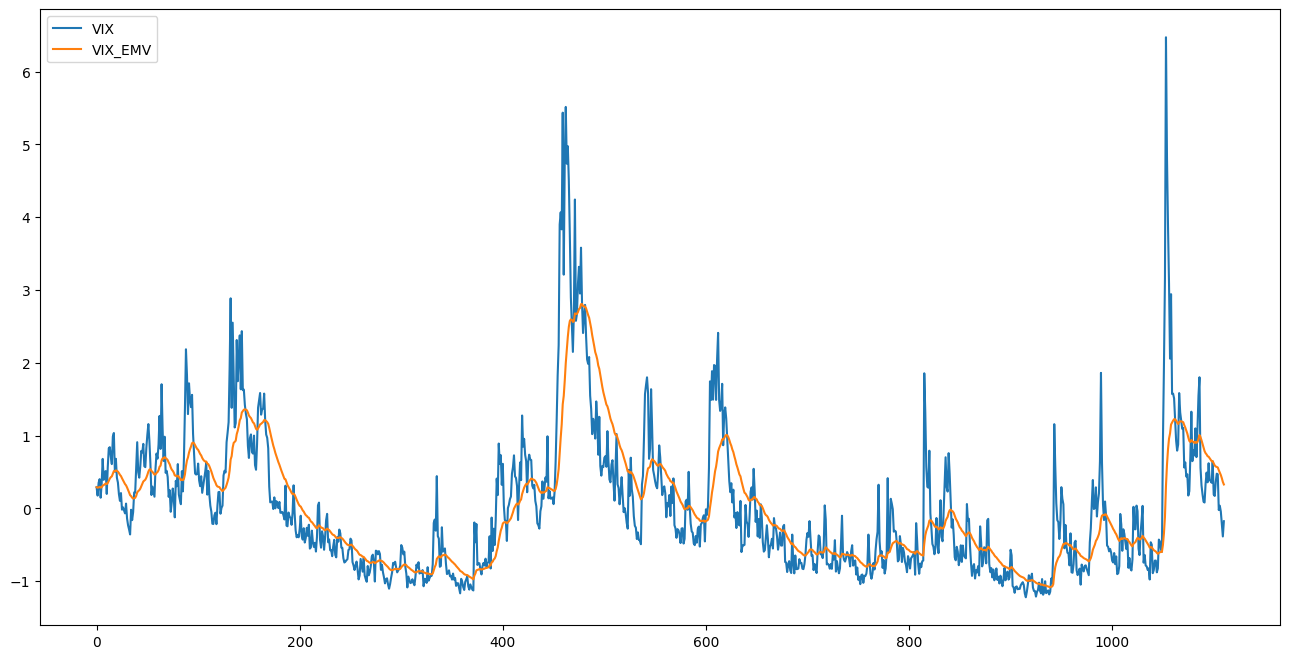

In [ ]:
for col in data.columns:
  if col in mva:
    data[[col, col+'_SMV']].plot(label=col+'_SMV', figsize=(16, 8))
    data[[col, col+'_EMV']].plot(label=col+'_EMV', figsize=(16, 8))

In [ ]:
data.columns

Index(['Y', 'Date', 'XAU BGNL', 'ECSURPUS', 'BDIY', 'CRY', 'DXY', 'JPY', 'GBP',
       'Cl1', 'VIX', 'GT10', 'USGG3M', 'GTDEM10Y', 'GTITL2YR', 'GTJPY2YR',
       'GTGBP20Y', 'MXUS', 'MXBR', 'XAU BGNL_SMV', 'XAU BGNL_EMV', 'BDIY_SMV',
       'BDIY_EMV', 'CRY_SMV', 'CRY_EMV', 'DXY_SMV', 'DXY_EMV', 'JPY_SMV',
       'JPY_EMV', 'GBP_SMV', 'GBP_EMV', 'VIX_SMV', 'VIX_EMV'],
      dtype='object')

# Anomaly Detection

In [ ]:
X = data.drop(['Date', 'Y'], axis=1)

In [ ]:
X

,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,GT10,...,CRY_SMV,CRY_EMV,DXY_SMV,DXY_EMV,JPY_SMV,JPY_EMV,GBP_SMV,GBP_EMV,VIX_SMV,VIX_EMV
0,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,0.290316,2.545494,...,-1.025461,-1.289247,1.380698,0.846232,0.042613,-0.058102,-0.051484,0.359670,0.399019,0.290316
1,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,0.174552,2.613819,...,-1.025461,-1.281921,1.380698,0.853606,0.042613,-0.060062,-0.051484,0.357238,0.399019,0.282848
2,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,0.350514,2.571773,...,-1.025461,-1.272959,1.380698,0.863624,0.042613,-0.059031,-0.051484,0.358611,0.399019,0.287213
3,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,0.400292,2.516963,...,-1.025461,-1.264944,1.380698,0.887233,0.042613,-0.048968,-0.051484,0.348041,0.399019,0.294509
4,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,0.145611,2.512458,...,-1.025461,-1.258789,1.380698,0.905348,0.042613,-0.032266,-0.051484,0.338152,0.399019,0.284902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,0.035636,-1.234922,...,-1.167531,-1.098360,0.075273,0.099232,-0.111186,-0.062606,-1.077030,-1.043920,0.563558,0.492379
1107,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,-0.044241,-1.171852,...,-1.152131,-1.084571,0.078083,0.106228,-0.100096,-0.040047,-1.071894,-1.036683,0.538437,0.457759
1108,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,-0.216730,-1.207892,...,-1.132672,-1.070759,0.074830,0.107315,-0.089838,-0.021005,-1.059691,-1.026781,0.486961,0.414243
1109,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,-0.386903,-1.239427,...,-1.112951,-1.055666,0.071319,0.105593,-0.080151,-0.006660,-1.046436,-1.020103,0.452463,0.362556


In [ ]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X)

anomaly_scores = iso_forest.decision_function(X)
anomaly_labels = iso_forest.predict(X)  # -1 = anomaly, 1 = normal
print("Anomaly Scores:", anomaly_scores)
print("Anomaly Scores:", anomaly_labels)

Anomaly Scores: [0.04107761 0.04087325 0.04303601 ... 0.04271881 0.04391058 0.04252854]
Anomaly Scores: [1 1 1 ... 1 1 1]


In [ ]:
anomaly_labels = 1 - (iso_forest.predict(X) == 1).astype(int)

In [ ]:
X['Anomaly_Labels'] = anomaly_labels
X['Anomaly_Scores'] = anomaly_scores

X

,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,GT10,...,DXY_SMV,DXY_EMV,JPY_SMV,JPY_EMV,GBP_SMV,GBP_EMV,VIX_SMV,VIX_EMV,Anomaly_Labels,Anomaly_Scores
0,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,0.290316,2.545494,...,1.380698,0.846232,0.042613,-0.058102,-0.051484,0.359670,0.399019,0.290316,0,0.041078
1,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,0.174552,2.613819,...,1.380698,0.853606,0.042613,-0.060062,-0.051484,0.357238,0.399019,0.282848,0,0.040873
2,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,0.350514,2.571773,...,1.380698,0.863624,0.042613,-0.059031,-0.051484,0.358611,0.399019,0.287213,0,0.043036
3,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,0.400292,2.516963,...,1.380698,0.887233,0.042613,-0.048968,-0.051484,0.348041,0.399019,0.294509,0,0.048737
4,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,0.145611,2.512458,...,1.380698,0.905348,0.042613,-0.032266,-0.051484,0.338152,0.399019,0.284902,0,0.044736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,0.035636,-1.234922,...,0.075273,0.099232,-0.111186,-0.062606,-1.077030,-1.043920,0.563558,0.492379,0,0.049059
1107,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,-0.044241,-1.171852,...,0.078083,0.106228,-0.100096,-0.040047,-1.071894,-1.036683,0.538437,0.457759,0,0.043134
1108,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,-0.216730,-1.207892,...,0.074830,0.107315,-0.089838,-0.021005,-1.059691,-1.026781,0.486961,0.414243,0,0.042719
1109,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,-0.386903,-1.239427,...,0.071319,0.105593,-0.080151,-0.006660,-1.046436,-1.020103,0.452463,0.362556,0,0.043911


In [ ]:
data

,Y,Date,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,CRY_SMV,CRY_EMV,DXY_SMV,DXY_EMV,JPY_SMV,JPY_EMV,GBP_SMV,GBP_EMV,VIX_SMV,VIX_EMV
0,0,2000-01-11,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,...,-1.025461,-1.289247,1.380698,0.846232,0.042613,-0.058102,-0.051484,0.359670,0.399019,0.290316
1,0,2000-01-18,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,...,-1.025461,-1.281921,1.380698,0.853606,0.042613,-0.060062,-0.051484,0.357238,0.399019,0.282848
2,0,2000-01-25,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,...,-1.025461,-1.272959,1.380698,0.863624,0.042613,-0.059031,-0.051484,0.358611,0.399019,0.287213
3,0,2000-02-01,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,...,-1.025461,-1.264944,1.380698,0.887233,0.042613,-0.048968,-0.051484,0.348041,0.399019,0.294509
4,1,2000-02-08,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,...,-1.025461,-1.258789,1.380698,0.905348,0.042613,-0.032266,-0.051484,0.338152,0.399019,0.284902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,...,-1.167531,-1.098360,0.075273,0.099232,-0.111186,-0.062606,-1.077030,-1.043920,0.563558,0.492379
1107,0,2021-03-30,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,...,-1.152131,-1.084571,0.078083,0.106228,-0.100096,-0.040047,-1.071894,-1.036683,0.538437,0.457759
1108,0,2021-04-06,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,...,-1.132672,-1.070759,0.074830,0.107315,-0.089838,-0.021005,-1.059691,-1.026781,0.486961,0.414243
1109,0,2021-04-13,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,...,-1.112951,-1.055666,0.071319,0.105593,-0.080151,-0.006660,-1.046436,-1.020103,0.452463,0.362556


In [ ]:
data['Anomaly_Labels'] = anomaly_labels
data['Anomaly_Scores'] = anomaly_scores
data

,Y,Date,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,...,DXY_SMV,DXY_EMV,JPY_SMV,JPY_EMV,GBP_SMV,GBP_EMV,VIX_SMV,VIX_EMV,Anomaly_Labels,Anomaly_Scores
0,0,2000-01-11,-1.424377,0.116941,-0.432277,-1.289247,0.846232,-0.058102,0.359670,-1.349527,...,1.380698,0.846232,0.042613,-0.058102,-0.051484,0.359670,0.399019,0.290316,0,0.041078
1,0,2000-01-18,-1.415478,0.019602,-0.423848,-1.175690,0.960528,-0.088487,0.321978,-1.230558,...,1.380698,0.853606,0.042613,-0.060062,-0.051484,0.357238,0.399019,0.282848,0,0.040873
2,0,2000-01-25,-1.416489,0.282989,-0.442193,-1.143014,1.008884,-0.044078,0.378516,-1.252575,...,1.380698,0.863624,0.042613,-0.059031,-0.051484,0.358611,0.399019,0.287213,0,0.043036
3,0,2000-02-01,-1.425389,0.443312,-0.470454,-1.148729,1.229563,0.096943,0.194769,-1.254892,...,1.380698,0.887233,0.042613,-0.048968,-0.051484,0.348041,0.399019,0.294509,0,0.048737
4,1,2000-02-08,-1.393734,0.789723,-0.487312,-1.169535,1.168019,0.209916,0.194769,-1.262618,...,1.380698,0.905348,0.042613,-0.032266,-0.051484,0.338152,0.399019,0.284902,0,0.044736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1106,0,2021-03-23,1.497764,0.867021,0.005523,-0.890078,0.123178,0.164727,-0.912427,-0.113874,...,0.075273,0.099232,-0.111186,-0.062606,-1.077030,-1.043920,0.563558,0.492379,0,0.049059
1107,0,2021-03-30,1.412004,0.763956,-0.077773,-0.884629,0.207669,0.287049,-0.931744,-0.006107,...,0.078083,0.106228,-0.100096,-0.040047,-1.071894,-1.036683,0.538437,0.457759,0,0.043134
1108,0,2021-04-06,1.528751,1.156174,-0.083227,-0.870486,0.123090,0.255105,-0.883215,-0.053231,...,0.074830,0.107315,-0.089838,-0.021005,-1.059691,-1.026781,0.486961,0.414243,0,0.042719
1109,0,2021-04-13,1.527558,1.233472,-0.059428,-0.836822,0.080624,0.201346,-0.923263,-0.020399,...,0.071319,0.105593,-0.080151,-0.006660,-1.046436,-1.020103,0.452463,0.362556,0,0.043911


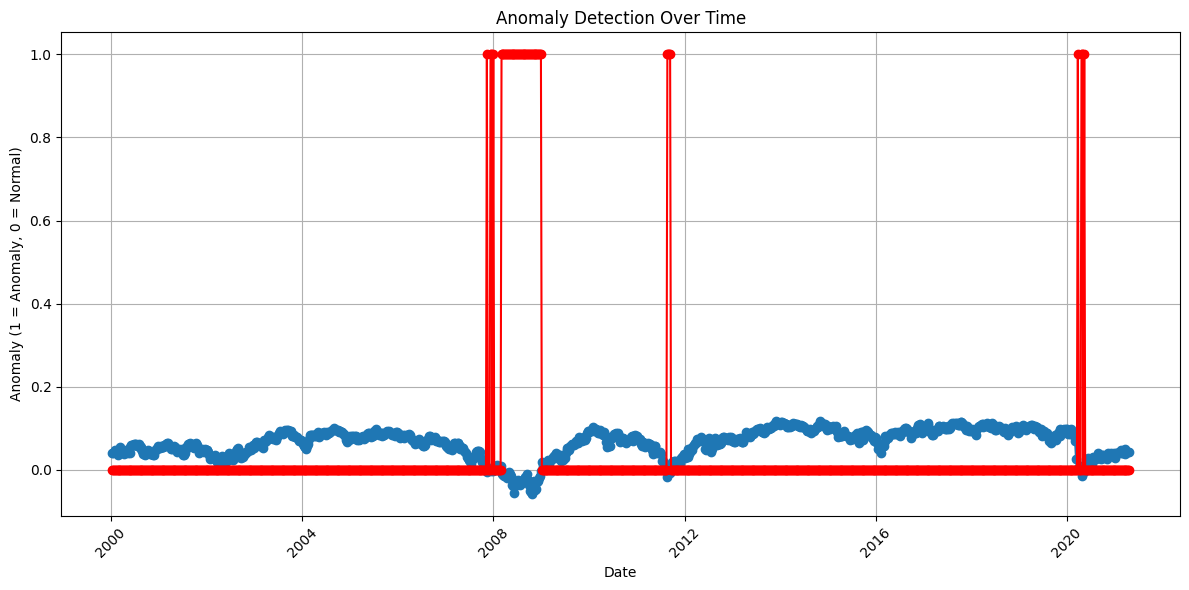

In [ ]:
def plot_anomaly_over_date(data):
    plt.figure(figsize=(12, 6))
    plt.plot(data['Date'], data['Anomaly_Scores'], marker='o', linestyle='-')
    plt.plot(data['Date'], data['Anomaly_Labels'], color='red', marker='o', linestyle='-')
    plt.xlabel('Date')
    plt.ylabel('Anomaly (1 = Anomaly, 0 = Normal)')
    plt.title('Anomaly Detection Over Time')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_anomaly_over_date(data)

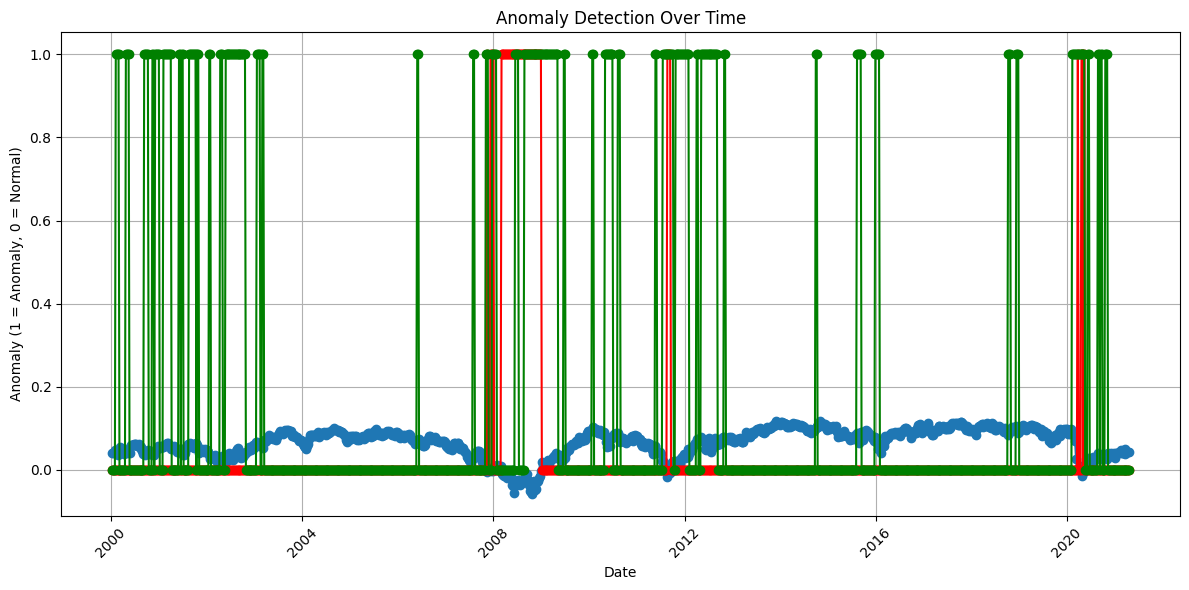

In [ ]:
def plot_anomaly_over_y(data):
    plt.figure(figsize=(12, 6))
    plt.plot(data['Date'], data['Anomaly_Scores'], marker='o', linestyle='-')
    plt.plot(data['Date'], data['Anomaly_Labels'], color='red', marker='o', linestyle='-')
    plt.plot(data['Date'], data['Y'], color='green', marker='o', linestyle='-')
    plt.xlabel('Date')
    plt.ylabel('Anomaly (1 = Anomaly, 0 = Normal)')
    plt.title('Anomaly Detection Over Time')
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_anomaly_over_y(data)

# Train the model

In [ ]:
y = data['Y']
X = data.drop(['Date', 'Y'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train

,XAU BGNL,ECSURPUS,BDIY,CRY,DXY,JPY,GBP,Cl1,VIX,GT10,...,DXY_SMV,DXY_EMV,JPY_SMV,JPY_EMV,GBP_SMV,GBP_EMV,VIX_SMV,VIX_EMV,Anomaly_Labels,Anomaly_Scores
865,0.713219,0.454763,-0.807605,-0.935094,0.461406,-0.362738,-1.265787,-0.692881,-0.964565,-1.290483,...,0.439004,0.436989,0.232485,0.184607,-0.763073,-0.778775,-0.364908,-0.485133,0,0.100354
993,0.599182,-0.607373,-0.606802,-0.970846,0.471956,0.211474,-1.289344,-0.314344,0.093518,-0.395497,...,0.426686,0.415765,0.402151,0.360099,-1.305991,-1.293175,-0.277622,-0.083129,0,0.106035
928,0.584659,0.377465,-0.333115,-0.870711,0.249431,0.565974,-1.209249,-0.318207,-1.022447,-0.635762,...,0.411793,0.365772,0.368052,0.378839,-1.288716,-1.269514,-1.045137,-1.036209,0,0.111739
780,0.385894,0.503432,-0.729762,-0.097230,-0.076577,1.091881,-0.083208,-0.138595,-0.601066,-0.754392,...,-0.604598,-0.521552,0.100709,0.265924,0.320408,0.219521,-0.683220,-0.607874,0,0.096614
734,0.533689,-0.369752,-0.583003,0.603530,-0.862846,-0.388449,0.293709,1.409158,-0.102123,-0.478088,...,-0.885772,-0.884188,-0.491111,-0.471977,0.143571,0.187260,-0.638304,-0.626335,0,0.110961
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
466,-0.300290,-2.116122,-0.709930,-0.277339,-0.901355,-1.289113,-0.191572,-0.660821,3.748186,-0.758146,...,-1.089594,-0.934521,-0.245039,-0.399280,1.038593,0.770355,1.941728,2.574879,1,-0.019731
121,-1.367339,0.829803,-0.615726,-1.197229,2.020843,1.668431,-0.483683,-1.316308,0.225489,1.343419,...,2.290055,2.274967,1.747460,1.741617,-0.630838,-0.622157,0.400447,0.290281,0,0.031267
1044,1.124828,-0.349712,-0.742158,-0.902697,0.565943,0.272246,-1.261075,-0.095720,-0.880057,-1.092265,...,0.603622,0.585437,0.116110,0.167124,-1.439326,-1.353889,-0.572743,-0.612078,0,0.090928
1095,1.947338,0.586457,-0.417402,-1.077593,-0.131791,-0.308200,-0.972262,-0.416317,0.619086,-1.734222,...,0.207824,0.196463,-0.093526,-0.107093,-1.251966,-1.222142,0.742838,0.709444,0,0.028876


In [ ]:
def run_model(model,X_train,X_test,y_train,y_test):
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    print(f"{model.__class__.__name__} Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test,y_pred)}")

In [ ]:
log_reg = LogisticRegression(random_state=42)
run_model(log_reg, X_train, X_test, y_train, y_test)

d_tree = DecisionTreeClassifier(random_state = 42)
run_model(d_tree, X_train,X_test,y_train,y_test)

r_forest = RandomForestClassifier(random_state = 42)
run_model(r_forest, X_train,X_test,y_train,y_test)

n_bayes = GaussianNB()
run_model(n_bayes, X_train,X_test,y_train,y_test)

knn_model = KNeighborsClassifier()
run_model(knn_model, X_train,X_test,y_train,y_test)

svm_model = SVC(random_state = 42)
run_model(svm_model, X_train,X_test,y_train,y_test)

LogisticRegression Accuracy: 0.8924

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.93       177
           1       0.78      0.67      0.72        46

    accuracy                           0.89       223
   macro avg       0.85      0.81      0.83       223
weighted avg       0.89      0.89      0.89       223

DecisionTreeClassifier Accuracy: 0.8565

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.92      0.91       177
           1       0.67      0.61      0.64        46

    accuracy                           0.86       223
   macro avg       0.78      0.76      0.77       223
weighted avg       0.85      0.86      0.85       223

RandomForestClassifier Accuracy: 0.9193

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       177
           1       0.87      0.72      0.79      

In [ ]:
def LSTM_model(X_train, X_test, y_train, y_test):
    # Resample to balance classes
    sm = SMOTE(random_state=42)
    X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

    # Normalize data
    scaler = MinMaxScaler()
    X_train_res = scaler.fit_transform(X_train_res)
    X_test = scaler.transform(X_test)

    # Reshape for LSTM
    X_train_res = X_train_res.reshape(X_train_res.shape[0], X_train_res.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    # Build the model
    model = Sequential()
    model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train_res.shape[1], 1)))
    model.add(Dropout(0.3))
    model.add(LSTM(units=64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(units=1, activation='sigmoid'))  # Use sigmoid for binary classification

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    lr_scheduler = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5)

    # Train the model
    history = model.fit(X_train_res, y_train_res, epochs=50, batch_size=32, validation_split=0.2,
              callbacks=[early_stopping, lr_scheduler])

    # Predict and evaluate
    y_pred = model.predict(X_test)
    y_pred = np.where(y_pred > 0.5, 1, 0)

    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.show()

    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")
    return model

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


35/35 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - accuracy: 0.6184 - loss: 0.6741 - val_accuracy: 0.0000e+00 - val_loss: 0.8920 - learning_rate: 0.0010
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.6124 - loss: 0.6700 - val_accuracy: 0.0000e+00 - val_loss: 1.0600 - learning_rate: 0.0010
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6154 - loss: 0.6661 - val_accuracy: 0.0000e+00 - val_loss: 1.0622 - learning_rate: 0.0010
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.6066 - loss: 0.6725 - val_accuracy: 0.0000e+00 - val_loss: 1.0614 - learning_rate: 0.0010
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.6214 - loss: 0.6653 - val_accuracy: 0.0000e+00 - val_loss: 0.9372 - learning_rate: 0.0010
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6355 - loss: 0.6531 - val_accuracy: 0.0000e+00 - val_loss: 0.9640 - learning_rate: 0.0010
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.6139 - loss: 0.6

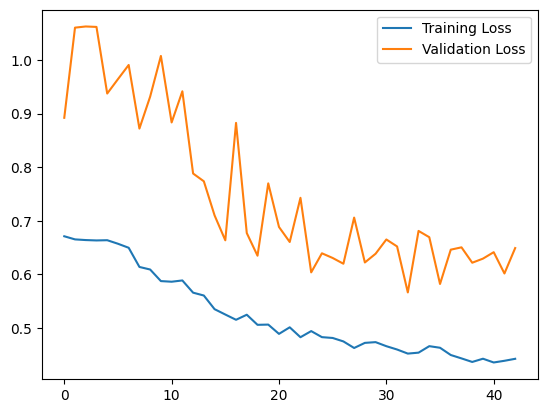

Accuracy: 0.7713

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.84       177
           1       0.46      0.72      0.56        46

    accuracy                           0.77       223
   macro avg       0.69      0.75      0.70       223
weighted avg       0.82      0.77      0.79       223



In [ ]:
lm = LSTM_model(X_train, X_test, y_train, y_test)

In [ ]:
def TCN_model(X_train, X_test, y_train, y_test, epochs=50, batch_size=32, filters=64, kernel_size=3, dropout_rate=0.2):
    """
    Defines and trains a Temporal Convolutional Network (TCN) model.
    """
    model = Sequential()

    # Temporal Convolutional Layers
    model.add(Conv1D(filters=filters, kernel_size=kernel_size, padding='causal', activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(BatchNormalization())
    model.add(Conv1D(filters=filters * 2, kernel_size=kernel_size, padding='causal', activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(BatchNormalization())

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1, activation='sigmoid'))  # Sigmoid for binary classification

    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.show()

    # Evaluate the model
    _, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"TCN Model Accuracy: {accuracy:.4f}")

    return model, history

Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 64ms/step - accuracy: 0.7109 - loss: 0.7295 - val_accuracy: 0.8427 - val_loss: 0.5686
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8068 - loss: 0.6381 - val_accuracy: 0.8596 - val_loss: 0.4870
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8586 - loss: 0.3831 - val_accuracy: 0.8708 - val_loss: 0.4897
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8749 - loss: 0.3318 - val_accuracy: 0.8652 - val_loss: 0.4666
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.8169 - loss: 0.4523 - val_accuracy: 0.8146 - val_loss: 0.4307
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8735 - loss: 0.3239 - val_accuracy: 0.8539 - val_loss: 0.4326
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8557 - loss: 0.3235 - val_accuracy: 0.8483 - val_loss: 0.4095
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8544 - loss: 0.3088 - val_accuracy: 0.8652 - val_loss: 0.

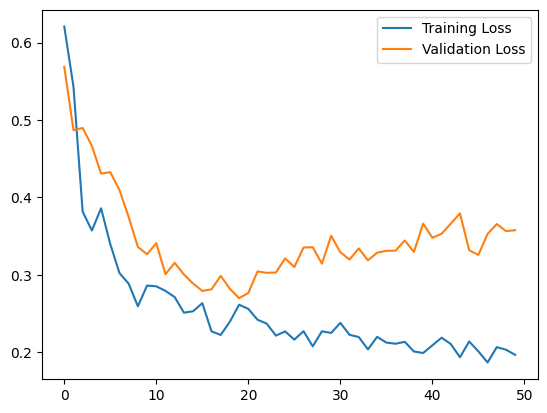

TCN Model Accuracy: 0.9058


In [ ]:
X_train = X_train.values.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.values.reshape(X_test.shape[0], X_test.shape[1], 1)
m, h = TCN_model(X_train, X_test, y_train, y_test)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

def XGBoost_model(X_train, X_test, y_train, y_test):
    """
    Trains and evaluates an XGBoost model.
    """
    # Define the model
    model = XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test set
    y_pred = model.predict(X_test)

    # Evaluate the model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"XGBoost Model Accuracy: {accuracy:.4f}")
    print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")

    return model

In [ ]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])

xgb_model = XGBoost_model(X_train, X_test, y_train, y_test)

XGBoost Model Accuracy: 0.9193

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       177
           1       0.87      0.72      0.79        46

    accuracy                           0.92       223
   macro avg       0.90      0.84      0.87       223
weighted avg       0.92      0.92      0.92       223

